# 3D Fluorescence Nuclei Segmentation (v1.4)

Welcome! This notebook guides you through 3D segmentation and quantification of nuclei and cells in fluorescence microscopy images.

**How to use this notebook:**
- Follow the numbered sections step by step.
- Adjust parameters in the **Inputs and Setup** section to match your experiment.
- Each code cell includes comments and explanations.
- Outputs and visualizations are clearly labeled.

---

# 1. Install Required Packages (run only once)
If you see errors about missing packages, run this cell.

In [1]:
from helpers.notebook_setup_helpers import install_required_packages

install_required_packages()


Installing aicsimageio[nd2]...
Defaulting to user installation because normal site-packages is not writeable
Installing nd2reader...
Defaulting to user installation because normal site-packages is not writeable
Installing xlsxwriter...
Defaulting to user installation because normal site-packages is not writeable
Installing reportlab...
Defaulting to user installation because normal site-packages is not writeable
Package installation complete.


# 2. Import Required Libraries
This cell imports all necessary libraries for image processing and visualization.
If you see an ImportError, make sure to install the missing package using pip (see cell 1).

In [2]:
# Check OpenCV version
import cv2
cv2.__version__

'4.5.4'

In [3]:
from helpers.notebook_setup_helpers import load_common_imports
from tqdm.auto import tqdm
from IPython.display import clear_output


globals().update(load_common_imports(profile="nuclei", enable_napari_interactive=True))


def step_progress(iterable, desc, **kwargs):
    # Keep a single visible progress bar by clearing previous loop output first.
    clear_output(wait=True)
    kwargs.pop("leave", None)
    kwargs.pop("position", None)
    kwargs.pop("dynamic_ncols", None)
    return tqdm(iterable, desc=desc, leave=False, position=0, dynamic_ncols=True, **kwargs)


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-02 14:49:01.085783: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-02 14:49:01.095456: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-02 14:49:01.182214: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-02 14:49:02.642637: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


#### Helper Functions



The reusable helper functions for this notebook are stored in `helpers/notebook_helpers.py`.

This keeps the notebook much lighter and makes the workflow sections easier to follow.

If you update the helper file, rerun the next code cell to reload the helpers.


In [4]:
from importlib import reload

import helpers.notebook_helpers as nuclei_helpers

reload(nuclei_helpers)
from helpers.notebook_helpers import *

print("Helper functions loaded from helpers/notebook_helpers.py")

Helper functions loaded from helpers/notebook_helpers.py


# 3. Inputs and Setup

In this section, you will:
- Set the path to your image file (e.g., `.nd2` or `.tif`)
- Define sample and staining information
- Adjust region of interest (ROI) and scaling
- Configure experiment-specific parameters

**Edit the variables in the next code cells to match your data and experiment.**

### File upload

In [5]:
# Load TIFF file and extract image data
input_file = 'EB-015_72h_M0_CUBE_20x.nd2'
big_image=True

# ROI = [500, 1650, 0, 1800, 20, 75] # EB-014_M1_ST_BX15043_20x.nd2 (TOP)
ROI = [0, 0, 0, 0, 0, 0] #XYZ - put 0 to keep the original value

In [6]:
meta = AICSImage(input_file)
if big_image:
    x0, x1, y0, y1, z0, z1 = ROI
    if x1==0:
        x1 = meta.shape[4]
    if y1==0:
        y1 = meta.shape[3]
    if z1==0:
        z1 = meta.shape[2]
    # Get lazy dask array in a known order, e.g. "TCZYX"
    lazy = meta.get_image_dask_data("ZYXC")
    sub = lazy[z0:z1, y0:y1, x0:x1, :]
    # Actually load this subset into memory
    img = sub.compute()
    ROI = [0, 0, 0, 0, 0, 0]
else:
    img = meta.get_image_data("XYZ", T=0) 

print(img.shape)

(50, 2400, 1200, 4)


In [7]:
# Get physical pixel sizes
r_X = meta.physical_pixel_sizes.X #um/px
r_Y = meta.physical_pixel_sizes.Y #um/px
r_Z = meta.physical_pixel_sizes.Z #um/px
print([r_X, r_Y, r_Z])

if big_image==False:
    imdata=meta.get_image_data()
    imtype=imdata.dtype
    bdepth=imtype.itemsize*8
    print(imtype)

with ND2Reader(input_file) as nd2:
    print("Date:", nd2.metadata.get("date"))
    print("Channels:", nd2.metadata.get("channels"))

[0.332776478412472, 0.332776478412472, 0.8]
Date: 2026-03-25 17:42:44
Channels: ['647_20x', '568_20x', '488_20x', 'DAPI_20x']


### Sample

In [8]:
nuclei_diameter=10 #um
cell_diameter=30 #um

cyto_factor=3.0
PCM_factor=4.0

stain_dict = {
    'NUCLEI': ['DAPI', 'DAPI_20x', 'Blue'],
    'MACRO': ['F4_80', '488_20x', 'Green'],
    'M1': ['iNOS', '568_20x', 'Red'],
    'M2': ['CD206', '647_20x', 'White']
}

cyto_markers=['F4_80','INOS','CD206']

# ── Nucleus splitting by shrinking ───────────────────────────────────────────
# The segmentation first shrinks the binary nuclei mask by a controlled amount.
# Thin bridges disappear first, while the larger round body of each nucleus
# remains. The shrunken cores are then used as watershed seeds on the original
# mask.
#
# Increase nuclei_bridge_shrink_factor  -> more splitting of touching nuclei
# Decrease nuclei_bridge_shrink_factor  -> less risk of splitting single nuclei
#
# Recommended starting range:
#  0.18 - conservative
#  0.22 - balanced
#  0.28 - aggressive
nuclei_bridge_shrink_factor = 0.28

# Flexible nucleus-size prior for splitting and seed filtering.
# The split model evaluates multiple diameters from min to max factor.
# Default is +/- 50% around nuclei_diameter.
nuclei_split_diameter_min_factor = 0.5
nuclei_split_diameter_max_factor = 1.5
nuclei_split_diameter_scales = 3

# Z splitting follows the measured anisotropy automatically from the current
# effective voxel sizes (Z versus mean of X and Y). Keep this multiplier at 1.0
# to follow the measured anisotropy exactly.
#  0.8 - softer Z separation
#  1.0 - anisotropy-driven default
#  1.2 - slightly stronger Z separation
nuclei_z_anisotropy_factor = 1.0

# Small eroded fragments are discarded before watershed seeding.
# This is expressed as a fraction of the expected nucleus volume.
nuclei_seed_min_fraction = 0.03

# Roundness filter for final nuclei labels on the largest XY slice.
# Circularity = 4*pi*area/perimeter^2. 1.0 is a perfect circle.
nuclei_min_roundness = 0.45


### Image

In [9]:
scale_factor=1.0
zoom_factors = [1.0, 1.0, 1.0] #XYZ
zoom_factors = [x * scale_factor for x in zoom_factors]

### Setup

In [10]:
name_setup = 'PRO_EB-015_cubes'
use_setup = True
trig_stardist = False  # Set to True to use StarDist model
multilabel=True

# 4. Information

This section calculates derived image parameters (cell and nuclei dimensions, volumes), builds the staining table from your inputs, and opens an interactive Napari viewer for contrast and gamma setup.

In [11]:
nuclei_radius=nuclei_diameter*0.5 #um
cell_radius=cell_diameter*0.5 #um

nuclei_volume=np.ceil(4.0*((nuclei_radius)**3.0)*np.pi/3.0) #um^3
cell_volume=np.ceil(4.0*((cell_radius)**3.0)*np.pi/3.0) #um^3

x0, x1, y0, y1, z0, z1 = ROI

if x1==0:
    x1 = img.shape[0]
if y1==0:
    y1 = img.shape[1]
if z1==0:
    z1 = img.shape[2]

if big_image:
    im_original = img.astype('float32')
    im_original_ROI = im_original.copy()
else:
    im_original = meta.get_image_data("ZYXC", S=0, T=0).astype('float32')
    im_original_ROI = im_original[z0:z1,y0:y1,x0:x1,:]

im_final_stack={'Original image': im_original_ROI}

In [12]:
if big_image:
    # Ensure `Original image` has axes Z,Y,X,C and squeeze singleton time axis
    orig = im_final_stack['Original image']
    try:
        shape = orig.shape
    except Exception:
        shape = None
    print('Original image shape before fix:', shape)
    if shape is not None:
        if len(shape) == 5:
            # common order Z,Y,X,C,T -> drop T if singleton
            if shape[4] == 1:
                orig = orig[..., 0]
        if len(orig.shape) == 4:
            # ensure channels are last: if last axis looks large (likely X), detect small axis as channel
            if orig.shape[-1] > 50:
                chan_axis = next((i for i, s in enumerate(orig.shape) if s < 50), None)
                if chan_axis is not None and chan_axis != 3:
                    import numpy as np
                    orig = np.moveaxis(orig, chan_axis, -1)
    im_final_stack['Original image'] = orig
    print('Original image shape after fix:', getattr(orig, 'shape', None))

Original image shape before fix: (50, 2400, 1200, 4)
Original image shape after fix: (50, 2400, 1200, 4)


### Information about the staining

In [13]:
# Define staining dictionary and create DataFrame
stain_dict = {k.upper(): [item.upper() if isinstance(item, str) else item for item in v] for k, v in stain_dict.items()}
stain_df = pd.DataFrame.from_dict(stain_dict, orient='index', columns=['Marker', 'Laser', 'Color'])
laser_order=nd2.metadata.get("channels")

# Map fluorophore to its order index
order_map = {name.strip().upper(): i for i, name in enumerate(laser_order)}
stain_df['order'] = stain_df['Laser'].map(order_map)

# Sort by that and drop helper column
stain_df = stain_df.sort_values('order').drop(columns='order')

stain_df.index.name = 'Condition'

if 'NUCLEI' not in stain_df.index:
    print('No nuclei condition!')

In [14]:
# Visualize each channel using napari
im_in=im_final_stack['Original image'].copy()

viewer_0 = napari.Viewer()
for c, c_name in step_progress(
    enumerate(stain_df['Marker']),
    total=len(stain_df['Marker']),
    desc='Step 04 - Visualize Channels',
    leave=False,
):
    #im_in = meta.get_image_data("ZYX", C=c, S=0, T=0).astype('float32')
    im_channel = im_in[:,:,:,c]

    # Stretch to [0, 255]
    im_8b = ((im_channel - im_channel.min()) / (im_channel.max() - im_channel.min()) * 255).clip(0, 255).astype('uint8')
    
    viewer_0.add_image(im_8b, name=f"{stain_df.index[c]} ({c_name})", 
                        colormap=stain_df['Color'][c], blending='additive')

    viewer_0.scale_bar.visible = True
    viewer_0.scale_bar.unit = 'um'

### Acquisition processing setup

In [15]:
# Setup for acquisition and contrast/gamma settings
im_in=im_final_stack['Original image'].copy()

stain_df = stain_df.reset_index(drop=False)
stain_initial_df = stain_df.copy()
stain_initial_df.set_index(['Condition', 'Marker', 'Laser'], inplace=True)
stain_initial_df[['Cont_min', 'Cont_max', 'Gamma']] = [0, 255, 1]
stain_complete_df=stain_initial_df.copy()

setup_path = f"{name_setup}_setup.csv"
if use_setup and os.path.exists(setup_path):
    stain_setup_df = pd.read_csv(setup_path)
    stain_setup_df.set_index(['Condition', 'Marker', 'Laser'], inplace=True)
    for idx in step_progress(stain_complete_df.index, desc='Step 05A - Load Setup Rows'):
        if idx in stain_setup_df.index:
            stain_complete_df.loc[idx] = stain_setup_df.loc[idx]
            stain_complete_df['Color'] = stain_initial_df['Color']
        else:
            use_setup = False

if not use_setup or not os.path.exists(setup_path):
    stain_complete_df=stain_initial_df.copy()
    settings.application.ipy_interactive = False
    viewer_1 = napari.Viewer()
    for c, idx in step_progress(
        enumerate(stain_complete_df.index),
        total=len(stain_complete_df.index),
        desc='Step 05B - Prepare Setup Viewer',
        leave=False,
    ):
        im_channel = im_in[:,:,:,c]
        im_channel = ((im_channel - im_channel.min()) / (im_channel.max() - im_channel.min()) * 255).clip(0, 255).astype('uint8')
        viewer_1.add_image(im_channel, name=f"{idx[0]} ({idx[1]})", colormap=stain_initial_df.loc[idx]['Color'], blending='additive')
    napari.run()
    image_layers = [layer for layer in viewer_1.layers if isinstance(layer, napari.layers.Image)]
    contrast_limits = {layer.name: layer.contrast_limits for layer in image_layers}
    gamma_val = {layer.name: layer.gamma for layer in image_layers}
    stain_complete_df.sort_index(inplace=True)
    for c, idx in step_progress(
        enumerate(stain_complete_df.index),
        total=len(stain_complete_df.index),
        desc='Step 05C - Collect Setup Values',
        leave=False,
    ):
        name = f"{idx[0]} ({idx[1]})"
        stain_complete_df.loc[idx, 'Cont_min'] = int(contrast_limits[name][0])
        stain_complete_df.loc[idx, 'Cont_max'] = int(contrast_limits[name][1])
        stain_complete_df.loc[idx, 'Gamma'] = gamma_val[name]
    if os.path.exists(setup_path):
        stain_setup_df = pd.read_csv(setup_path)
        stain_setup_df.set_index(['Condition', 'Marker', 'Laser'], inplace=True)
        for idx in step_progress(stain_complete_df.index, desc='Step 05D - Write Setup Rows'):
            stain_setup_df.loc[idx] = stain_complete_df.loc[idx]
    else:
        stain_setup_df = stain_complete_df.copy()
    stain_csv_setup_df = stain_setup_df.reset_index().sort_values(by='Condition')
    stain_csv_setup_df = stain_csv_setup_df[['Condition', 'Marker', 'Laser', 'Cont_min', 'Cont_max', 'Gamma']]
    stain_csv_setup_df.to_csv(setup_path, index=False)

stain_df = stain_df.set_index('Condition')
stain_complete_df = stain_complete_df.reset_index().set_index('Condition')
stain_complete_df = stain_complete_df.loc[stain_df.index]
stain_complete_df = stain_complete_df[['Marker', 'Laser', 'Color', 'Cont_min', 'Cont_max', 'Gamma']]
original_stain_complete_df=stain_complete_df.copy()

In [16]:
# Display stain settings DataFrame
stain_complete_df

,Marker,Laser,Color,Cont_min,Cont_max,Gamma
Condition,,,,,,
M2,CD206,647_20X,WHITE,20,255,1
M1,INOS,568_20X,RED,17,212,1
MACRO,F4_80,488_20X,GREEN,17,218,1
NUCLEI,DAPI,DAPI_20X,BLUE,12,138,1


# 5. Image Processing and Segmentation

This section normalizes the image, resamples to isotropic voxels, denoises, applies contrast and gamma adjustments, and then segments the structures of interest.

(<Figure size 1500x200 with 4 Axes>,
 array([<Axes: title={'center': 'M2'}>, <Axes: title={'center': 'M1'}>,
        <Axes: title={'center': 'MACRO'}>,
        <Axes: title={'center': 'NUCLEI'}>], dtype=object))

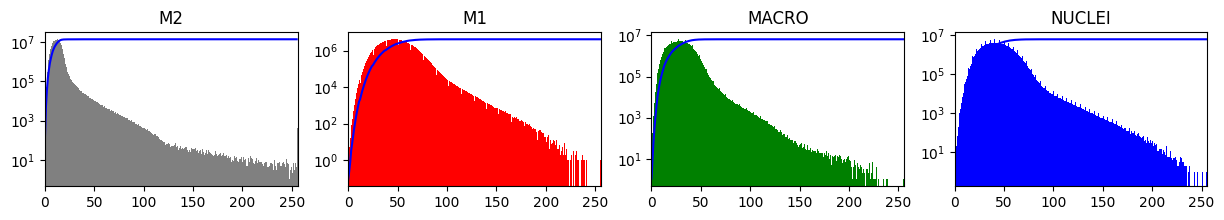

In [17]:
# Load and normalize image data for all channels
im_final_stack['Normalized image'] = normalize_image_channels(im_final_stack['Original image'])

# Plot histogram for each channel
hist_plot(im_final_stack['Normalized image'], stain_complete_df)


(<Figure size 1500x200 with 4 Axes>,
 array([<Axes: title={'center': 'M2'}>, <Axes: title={'center': 'M1'}>,
        <Axes: title={'center': 'MACRO'}>,
        <Axes: title={'center': 'NUCLEI'}>], dtype=object))

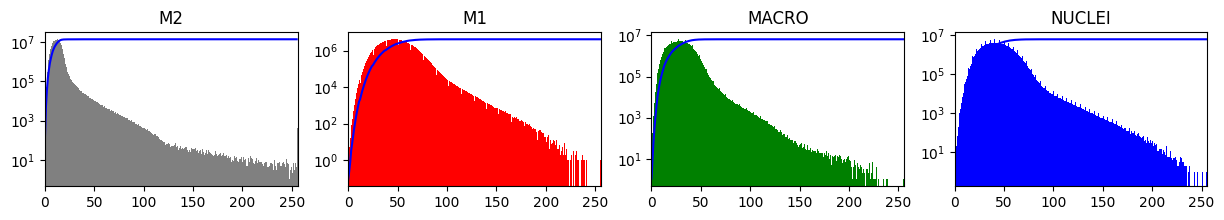

In [18]:
# Adapt resolution to isotropic
im_final_stack['Zoomed image'], r_zX, r_zY, r_zZ = resample_to_isotropic(
    im_final_stack['Normalized image'],
    zoom_factors,
    meta=meta
)

hist_plot(im_final_stack['Zoomed image'], stain_complete_df)


(<Figure size 1500x200 with 4 Axes>,
 array([<Axes: title={'center': 'M2'}>, <Axes: title={'center': 'M1'}>,
        <Axes: title={'center': 'MACRO'}>,
        <Axes: title={'center': 'NUCLEI'}>], dtype=object))

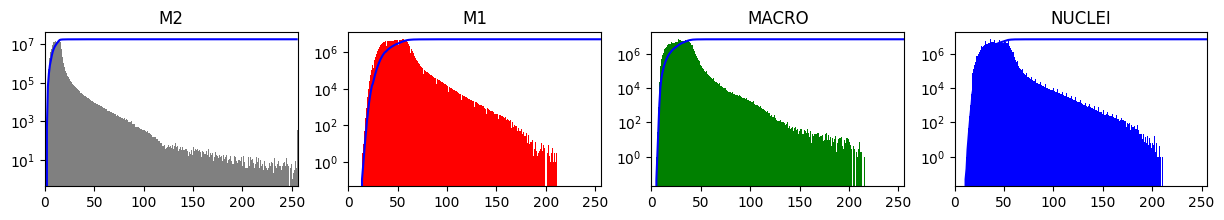

In [19]:
# Noise removal using median filter
im_final_stack['Denoised image'] = apply_median_denoise(im_final_stack['Zoomed image'])
hist_plot(im_final_stack['Denoised image'], stain_complete_df)


(<Figure size 1500x200 with 4 Axes>,
 array([<Axes: title={'center': 'M2'}>, <Axes: title={'center': 'M1'}>,
        <Axes: title={'center': 'MACRO'}>,
        <Axes: title={'center': 'NUCLEI'}>], dtype=object))

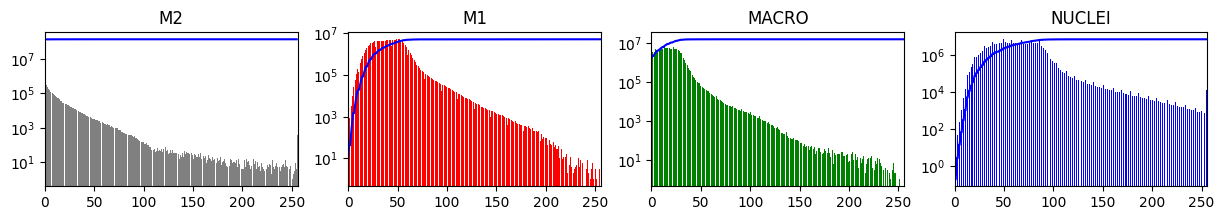

In [20]:
# Contrast and gamma adjustment for each channel
im_final_stack['Adjusted image'] = apply_contrast_gamma_per_channel(
    im_final_stack['Denoised image'],
    stain_complete_df
)
hist_plot(im_final_stack['Adjusted image'], stain_complete_df)


(<Figure size 1500x200 with 4 Axes>,
 array([<Axes: title={'center': 'M2'}>, <Axes: title={'center': 'M1'}>,
        <Axes: title={'center': 'MACRO'}>,
        <Axes: title={'center': 'NUCLEI'}>], dtype=object))

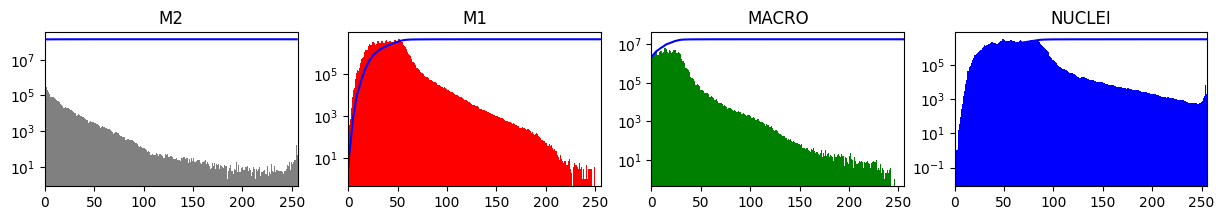

In [21]:
# Gaussian filter for smoothing
im_final_stack['Filtered image'] = apply_gaussian_smoothing(
    im_final_stack['Adjusted image'],
    sigma=0.5
)
hist_plot(im_final_stack['Filtered image'], stain_complete_df)


In [22]:
# Export histograms
output_path=Path(input_file).stem + '_histograms.xlsx'
im_in = im_final_stack['Adjusted image'].copy()

with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    for c in step_progress(range(im_in.shape[3]), desc='Step 08 - Export Histograms'):
        # Example input: 3D array (e.g. image stack)
        im3d = im_in[:, :, :, c].copy()

        # Compute histogram
        values, counts = np.unique(im3d.astype('int'), return_counts=True)
        hist = np.zeros(256, dtype=int)
        hist[values] = counts

        # Calculate totals, percentages, and cumulative values
        total = hist.sum()
        percentage = (hist / total) * 100
        cumulative = np.cumsum(hist)
        cumulative_percentage = np.cumsum(percentage)

        # Build DataFrame
        df = pd.DataFrame({
            "Pixel_Value": np.arange(256),
            "Count": hist,
            "Percentage": percentage,
            "Cumulative_Count": cumulative,
            "Cumulative_Percentage": cumulative_percentage
        })

        idx = stain_complete_df.index[c]
        marker = stain_complete_df.loc[idx, 'Marker']

        # Write each to a different sheet
        df.to_excel(writer, sheet_name=marker, index=False)
    
print(f"Saved to: {output_path}")

Saved to: EB-015_72h_M0_CUBE_20x_histograms.xlsx


(<Figure size 1500x200 with 4 Axes>,
 array([<Axes: title={'center': 'M2'}>, <Axes: title={'center': 'M1'}>,
        <Axes: title={'center': 'MACRO'}>,
        <Axes: title={'center': 'NUCLEI'}>], dtype=object))

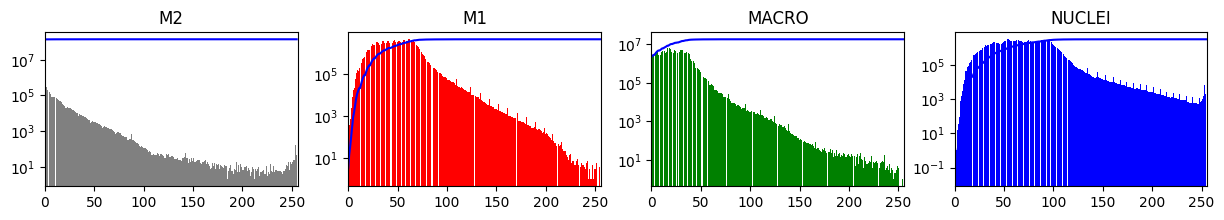

In [23]:
# Histogram equalization, supporting thresholding
im_final_stack['Equalized image'] = apply_histogram_equalization_per_channel(
    im_final_stack['Filtered image'],
    num_plateaus=2,
    plateau_factor=0.7
)
hist_plot(im_final_stack['Equalized image'], stain_complete_df)


In [ ]:
# Thresholding using Otsu, Sauvola, statistical background, gain filtering
im_in = im_final_stack["Equalized image"].copy()
im_out = im_in.copy()

# Sizes
nuclei_size = int(nuclei_diameter / (np.mean([r_zX, r_zY])))
cell_size = int(cell_diameter / (np.mean([r_zX, r_zY])))

for c in step_progress(range(im_in.shape[3]), desc='Step 09 - Threshold Channels'):
    img = sitk.GetImageFromArray(im_in[:, :, :, c])

    # Stretch for Otsu
    rescaler = sitk.RescaleIntensityImageFilter()
    rescaler.SetOutputMinimum(0)
    rescaler.SetOutputMaximum(255)
    stretched = rescaler.Execute(img)


    # Otsu thresholds
    th_filter = sitk.OtsuThresholdImageFilter()
    _ = th_filter.Execute(stretched)
    otsu_value = th_filter.GetThreshold()

    _ = th_filter.Execute(img)
    otsu_value2 = th_filter.GetThreshold()

    if stain_complete_df.index[c] == "NUCLEI":
        window_size = 1 * nuclei_size #+ 1
    else:
        window_size = 4 * cell_size + 1

    # Convert to array
    arr = sitk.GetArrayFromImage(img) #.astype(np.float32)

    # Sauvola threshold map
    sauvola_value = threshold_sauvola(arr, window_size=int(window_size))

    # -------- GLOBAL statistical background, excluding zeros --------
    non_zero = arr[arr > 0]

    if non_zero.size > 0:
        hist, bins = np.histogram(non_zero, bins=256, range=(0, non_zero.max()))
        mode_bin = bins[np.argmax(hist)]
        print(mode_bin)
        bg_mask = (arr >= mode_bin - 5) & (arr <= mode_bin + 5) & (arr > 0) 
        gain_tot=6.0

        gain_ass=gain_tot*(255.0-4.0*mode_bin)/255.0
        bg_vals = arr[bg_mask]

        if bg_vals.size < 50:
            p10 = np.percentile(non_zero, 10)
            bg_vals = non_zero[non_zero <= p10]
    else:
        bg_vals = arr

    bg_mean = bg_vals.mean()
    bg_std = bg_vals.std() + 1e-6

    bg_mean_z = arr.mean()
    bg_std_z = arr.std() + 1e-6
    z = 3.0
    statistical_thr = bg_mean_z + z * bg_std_z

    # ---------------------------------------------------------------

    # 1) Soften Sauvola if it is too aggressive for large/bright cells
    # Clip Sauvola so it cannot exceed a few std above the global (zero‑including) mean
    max_sauvola = bg_mean_z + 2.0 * bg_std_z
    sauvola_clipped = np.minimum(sauvola_value, max_sauvola)

    # Final combined threshold map (slightly less Sauvola weight)
    final_thr = (
        0.60 * sauvola_clipped +
        0.25 * statistical_thr +
        0.15 * otsu_value2
    )

    # Extra improvement: intensity gain check (global, using non-zero-based bg_mean)
    gain = arr / (bg_mean + 1e-6)
    mask_gain = gain > gain_ass    # tune 2–5 depending on SNR

    # 2) Rescue pixels: strong gain but slightly under final_thr
    primary = (arr > final_thr) & mask_gain
    rescue = (gain > (gain_ass+3.0)) & (arr > statistical_thr)   # gain threshold > primary, to keep it conservative

    arrayseg = primary | rescue

    if stain_complete_df.index[c] != 'NUCLEI':
        min_size = np.ceil(0.8 * np.pi * ((nuclei_size / 2) ** 2))
    else:
        min_size= np.ceil(0.4 * np.pi * ((nuclei_size / 2) ** 2))

    # Remove small islands
    
    im_out[:, :, :, c] = remove_small_islands(arrayseg, min_size)

im_final_stack["Threshold image"] = im_out.copy()

Step 09 - Threshold Channels:   0%|                                                     | 0/4 [00:00<?, ?it/s]

In [ ]:
# Segmentation of nuclei using watershed or StarDist
from skimage.segmentation import relabel_sequential

if 'NUCLEI' in stain_df.index:
    im_in = im_final_stack['Threshold image'].copy()

    for c in step_progress(range(im_in.shape[3]), desc='Step 10 - Segment Nuclei'):
        if stain_complete_df.index[c] == 'NUCLEI':
            if trig_stardist:
                im_in = im_final_stack['Filtered image'].copy()
                transl = stardist3d_from_2d(
                    img_3d=im_in[:, :, :, c],
                    nucleus_radius=nuclei_diameter / 2.0,
                    voxel_size=(r_zZ, r_zY, r_zX),
                )
                im_mask = transl > 0
                im_mask = morphology.binary_erosion(
                    im_mask, footprint=np.ones((2, 2, 2))
                ).astype(im_mask.dtype)
                im_out, num = label((transl * im_mask) > 0)

            else:
                # Watershed-based segmentation with multi-scale erosion and EDT fallback
                binary_mask = im_in[:, :, :, c].astype(bool)
                
                im_out, debug_info = segment_nuclei_watershed(
                    binary_mask=binary_mask,
                    r_zX=r_zX,
                    r_zY=r_zY,
                    r_zZ=r_zZ,
                    nuclei_diameter=nuclei_diameter,
                    nuclei_z_anisotropy_factor=nuclei_z_anisotropy_factor,
                    nuclei_bridge_shrink_factor=nuclei_bridge_shrink_factor,
                    nuclei_split_diameter_min_factor=nuclei_split_diameter_min_factor,
                    nuclei_split_diameter_max_factor=nuclei_split_diameter_max_factor,
                    nuclei_split_diameter_scales=nuclei_split_diameter_scales,
                    nuclei_seed_min_fraction=nuclei_seed_min_fraction,
                    nuclei_min_roundness=nuclei_min_roundness,
                )
                
                # Extract debug info for print statement
                z_anisotropy = debug_info['z_anisotropy']
                z_split_weight = debug_info['z_split_weight']
                scales_with_seeds = debug_info['scales_with_seeds']
                added_peak_seed_count = debug_info['added_peak_seed_count']
                added_seed_count = debug_info['added_seed_count']
                restored_isolated_count = debug_info['restored_isolated_count']
                erosion_triplets = debug_info['erosion_triplets']
                boundary_components = debug_info['boundary_components']
                dmin = debug_info['dmin']
                dmax = debug_info['dmax']
                n_scales = debug_info['n_scales']
                min_seed_vox = debug_info['min_seed_vox']
                removed_by_roundness = debug_info['removed_by_roundness']
                
                er_z_values = [e[0] for e in erosion_triplets] if erosion_triplets else [1]
                er_y_values = [e[1] for e in erosion_triplets] if erosion_triplets else [1]
                er_x_values = [e[2] for e in erosion_triplets] if erosion_triplets else [1]

                print(
                    f"Nuclei found: {int(im_out.max())} "
                    f"(shrink_factor={nuclei_bridge_shrink_factor}, "
                    f"diameter_range=[{dmin:.2f},{dmax:.2f}]x, scales={n_scales}, "
                    f"scales_with_seeds={scales_with_seeds}, peak_seeds={added_peak_seed_count}, "
                    f"z_anisotropy={z_anisotropy:.2f}, z_weight={z_split_weight:.2f}, "
                    f"erosion Z={min(er_z_values)}-{max(er_z_values)} "
                    f"Y={min(er_y_values)}-{max(er_y_values)} "
                    f"X={min(er_x_values)}-{max(er_x_values)} vox, "
                    f"min_seed_vox={min_seed_vox} (boundary={3}), "
                    f"boundary_components={len(boundary_components)}, "
                    f"added_component_seeds={added_seed_count}, "
                    f"restored_isolated_voxels={restored_isolated_count}, "
                    f"removed_by_roundness={removed_by_roundness})"
                )

            im_segmentation_stack = {'Nuclei': im_out}

            cm_rand = np.random.rand(int(np.max(im_segmentation_stack['Nuclei'])), 3)
            cm_rand[0, :] = [0.0, 0.0, 0.0]

            colormaps_rand = Colormap(cm_rand)


In [ ]:
# Segmentation of cytoplasm
im_in = im_final_stack['Threshold image'].copy()

if 'im_segmentation_stack' not in globals() or 'Nuclei' not in im_segmentation_stack:
    raise RuntimeError("Run cell 38 first so nuclei segmentation creates im_segmentation_stack['Nuclei'].")

if ('NUCLEI' in stain_df.index) | ('CYTOPLASM' in stain_df.index) | len(cyto_markers) > 0:
    im_out = np.zeros_like(im_in[:, :, :, 0], dtype=np.int32)

    for c in step_progress(range(im_in.shape[3]), desc='Step 11A - Segment Cytoplasm'):
        if stain_df.index[c] == 'CYTOPLASM':
            distance = ndi.distance_transform_edt(im_in[:, :, :, c], sampling=[r_zZ, r_zY, r_zX])
            radius_X = int((nuclei_diameter / 2.0) / r_zX)
            radius_Y = int((nuclei_diameter / 2.0) / r_zY)
            radius_Z = int((nuclei_diameter / 2.0) / r_zZ)
            coords = peak_local_max(
                distance,
                footprint=make_anisotropic_footprint(radius_Z, radius_Y, radius_X),
                labels=im_in[:, :, :, c].astype(np.int32),
            )
            mask = np.zeros(distance.shape, dtype=bool)
            mask[tuple(coords.T)] = True
            markers, _ = label(mask)
            im_out = watershed(-distance, im_segmentation_stack['Nuclei'], mask=im_in[:, :, :, c])

    if 'CYTOPLASM' not in stain_df.index:
        if len(cyto_markers) == 0:
            im_out = grow_labels(im_segmentation_stack['Nuclei'], cyto_factor)
        else:
            im_out = im_segmentation_stack['Nuclei'] > 0
            for c in step_progress(range(im_in.shape[3]), desc='Step 11B - Apply Cyto Markers'):
                idx = stain_complete_df.index[c]
                marker = stain_complete_df.loc[idx, 'Marker']
                if marker in cyto_markers:
                    im_out = im_out + im_in[:, :, :, c]
            binary_mask = (im_out > 0).copy()
            im_out = grow_markers_within_islands_limited(
                im_segmentation_stack['Nuclei'], binary_mask, max_distance=10.0
            )

        stain_complete_df.loc['CYTOPLASM'] = ['', '', '', '', '', '']

    im_segmentation_stack['Cytoplasm'] = im_out.copy()

In [ ]:
# Segmentation of the pericellular matrix (PCM)
im_in=im_final_stack['Threshold image'].copy()

if ('NUCLEI' in stain_df.index)|('CYTOPLASM' in stain_df.index):
    im_out = np.zeros_like(im_in[:,:,:,0], dtype=np.int32)
    if len(cyto_markers)==0:
        im_out=grow_labels(im_segmentation_stack['Nuclei'], PCM_factor)
    else:
        P_factor = int(PCM_factor-cyto_factor)
        im_out=grow_labels(im_segmentation_stack['Cytoplasm'], P_factor)
    im_out=im_out-im_segmentation_stack['Cytoplasm']
        
    im_segmentation_stack['PCM'] = im_out.copy()

In [ ]:
# Assign segmented nuclei labels to other channels (cell assignment)
im_in=im_final_stack['Threshold image'].copy()

if ('NUCLEI' in stain_df.index)|('CYTOPLASM' in stain_df.index):
    for c in step_progress(range(im_in.shape[3]), desc='Step 12 - Assign Labels To Channels'):
        if (stain_df.index[c] != 'NUCLEI') & (stain_df.index[c] != 'CYTOPLASM') & (stain_df.index[c] != 'PCM'):
            im_segmentation_stack[stain_df.index[c]] = im_in[:, :, :, c] * (im_segmentation_stack['Cytoplasm'] + im_segmentation_stack['PCM'])
            im_segmentation_stack[stain_df.index[c] + '_cyto'] = im_in[:, :, :, c] * (im_segmentation_stack['Cytoplasm'])
            im_segmentation_stack[stain_df.index[c] + '_PCM'] = im_in[:, :, :, c] * (im_segmentation_stack['PCM'])

In [ ]:
# # Evaluate aggregates
# if ('NUCLEI' in stain_df.index)|('CYTOPLASM' in stain_df.index):
#     im_out,num_aggregates=label(grow_labels(im_segmentation_stack['Cytoplasm'],2.0)>0)
#     im_segmentation_stack['Aggregates']=im_out*(im_segmentation_stack['Cytoplasm']>0)

In [24]:
# Visualize original, denoised, filtered, corrected, thresholded, assigned, and segmented images
viewer_0 = napari.Viewer()
scale_zoom=(r_zZ, r_zY, r_zX)

for c in step_progress(range(im_in.shape[3]), desc='Step 13A - Add Layers To Viewer 0'):
    idx = stain_complete_df.index[c]
    marker = stain_complete_df.loc[idx, 'Marker']
    color = stain_complete_df['Color'].iloc[c]
    #viewer_0.add_image(im_final_stack['Normalized image'], name=f'NORMALIZED {idx} ({marker})', colormap=color, blending='additive')
    viewer_0.add_image(im_final_stack['Original image'][:, :, :, c], name=f'ORIGINAL {idx} ({marker})', colormap=color, blending='additive', scale=[r_Z, r_Y, r_X])
    viewer_0.add_image(im_final_stack['Zoomed image'][:, :, :, c], name=f'ZOOMED {idx} ({marker})', colormap=color, blending='additive', scale=scale_zoom)
    viewer_0.add_image(im_final_stack['Denoised image'][:, :, :, c], name=f'DENOISED {idx} ({marker})', colormap=color, blending='additive', scale=scale_zoom)
    viewer_0.add_image(im_final_stack['Adjusted image'][:, :, :, c], name=f'CORRECTED {idx} ({marker})', colormap=color, blending='additive', scale=scale_zoom)
    viewer_0.add_image(im_final_stack['Filtered image'][:, :, :, c], name=f'FILTERED {idx} ({marker})', colormap=color, blending='additive', scale=scale_zoom)
    viewer_0.add_image(im_final_stack['Equalized image'][:, :, :, c], name=f'EQ {idx} ({marker})', colormap=color, blending='additive', scale=scale_zoom)
    #viewer_0.add_image(im_final_stack['Threshold image'][:, :, :, c].astype('uint8'), name=f'THRESHOLD {idx} ({marker})', contrast_limits=[0, 1], colormap=color, blending='additive', scale=scale_zoom)    
    #if stain_complete_df.index[c] == 'NUCLEI':
        # Keep full integer label IDs to avoid wrap-around when nuclei count > 255.
        #viewer_0.add_labels(im_segmentation_stack['Nuclei'].astype(np.int32), name=f'{idx} ({marker})', blending='additive', scale=scale_zoom) #, colormap=colormaps_rand, contrast_limits=[0, np.max(im_nuclei_segmented)], blending='additive')
viewer_0.scale_bar.visible = True
viewer_0.scale_bar.unit = 'um'

if ('NUCLEI' in stain_complete_df.index)|('CYTOPLASM' in stain_complete_df.index):
    viewer_1 = napari.Viewer()

    im_in=im_final_stack['Threshold image'].copy()
    
    for c in step_progress(range(len(stain_complete_df.index)), desc='Step 13B - Add Labels To Viewer 1'):
        idx = stain_complete_df.index[c]
        marker = stain_complete_df.loc[idx, 'Marker']
        if stain_complete_df.index[c] == 'NUCLEI':
            viewer_1.add_labels(im_segmentation_stack['Nuclei'].astype(np.int32), name=f'{idx} ({marker})', blending='additive', scale=scale_zoom) #, colormap=colormaps_rand, contrast_limits=[0, np.max(im_nuclei_segmented)], blending='additive')
        if stain_complete_df.index[c] == 'CYTOPLASM':
            viewer_1.add_labels(im_segmentation_stack['Cytoplasm'].astype(np.int32), blending='additive', name=f'{idx} ({marker})', scale=scale_zoom) #, colormap=colormaps_rand, contrast_limits=[0, np.max(im_nuclei_segmented)], blending='additive')
            viewer_1.add_labels(im_segmentation_stack['PCM'].astype(np.int32), name=f'PCM', blending='additive', scale=scale_zoom) #, colormap=colormaps_rand, contrast_limits=[0, np.max(im_nuclei_segmented)], blending='additive')
            #viewer_1.add_labels(im_segmentation_stack['Aggregates'].astype('uint8'), name=f'AGGREGTES', blending='additive', scale=scale_zoom) #, colormap=colormaps_rand, contrast_limits=[0, np.max(im_aggregates)], blending='additive')
        if (stain_complete_df.index[c] != 'NUCLEI') & (stain_complete_df.index[c] != 'CYTOPLASM') & (stain_complete_df.index[c] != 'PCM'):
            viewer_1.add_labels(im_segmentation_stack[stain_df.index[c]].astype(np.int32), name=f'{idx} ({marker})', blending='additive', scale=scale_zoom) #, colormap=colormaps_rand, contrast_limits=[0, np.max(im_nuclei_segmented)], blending='additive')
    viewer_1.scale_bar.visible = True
    viewer_1.scale_bar.unit = 'um'

# 6. Quantification and Analysis

This section quantifies nuclei and cell properties, computes statistics, and visualizes distributions. Results are exported for further analysis.

In [31]:
labels_dict = {}

r_xyz = (r_zX, r_zY, r_zZ)
zooms = zoom_factors
nuc_positions, nuc_sizes, cyto_positions, cyto_sizes = compute_nuclei_cytoplasm_stats(im_segmentation_stack, r_xyz, zooms)

c_nuc = None
c_cyto = None

if 'NUCLEI' in stain_complete_df.index:
    c_nuc = stain_complete_df.index.get_loc('NUCLEI')
if 'CYTOPLASM' in stain_complete_df.index:
    c_cyto = stain_complete_df.index.get_loc('CYTOPLASM')

if c_nuc is not None:
    nuc_marker = stain_complete_df['Marker'][c_nuc]
    labels_dict[nuc_marker] = [
        stain_complete_df.index[c_nuc],
        stain_complete_df['Laser'][c_nuc],
        stain_complete_df['Color'][c_nuc],
        int(np.max(im_segmentation_stack['Nuclei'])),
        (),  # Shared labels placeholder
        tuple(nuc_positions),
        (),
        tuple(nuc_sizes),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        ()
    ]

if c_cyto is not None:
    cyto_marker = stain_complete_df['Marker'][c_cyto]
    labels_dict[cyto_marker] = [
        stain_complete_df.index[c_cyto],
        stain_complete_df['Laser'][c_cyto],
        stain_complete_df['Color'][c_cyto],
        int(np.max(im_segmentation_stack['Cytoplasm'])),
        (),
        (),
        tuple(cyto_positions),
        (),
        tuple(cyto_sizes),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        ()
    ]

filtered_img = im_final_stack['Filtered image']
num_channels = filtered_img.shape[3]

for c in step_progress(range(num_channels), desc='Step 14A - Quantify Marker Stats'):
    condition = stain_complete_df.index[c]
    if condition in ['NUCLEI', 'CYTOPLASM', 'PCM']:
        continue
    marker = stain_complete_df['Marker'][c]

    shared_labels, m_sizes, m_avg, m_std, m_cyto_sizes, m_cyto_avg, m_cyto_std, m_pcm_sizes, m_pcm_avg, m_pcm_std = compute_marker_stats_for_marker(c, im_segmentation_stack, filtered_img, r_xyz, zooms)

    labels_dict[marker] = [
        condition,
        stain_complete_df['Laser'][c],
        stain_complete_df['Color'][c],
        len(shared_labels),
        tuple(sorted(shared_labels)),
        tuple(nuc_positions[i-1] for i in shared_labels) if len(shared_labels)>0 else (),
        tuple(cyto_positions[i-1] for i in shared_labels) if len(shared_labels)>0 else (),
        tuple(nuc_sizes[i-1] for i in shared_labels) if len(shared_labels)>0 else (),
        tuple(cyto_sizes[i-1] for i in shared_labels) if len(shared_labels)>0 else (),
        tuple(m_sizes),
        tuple(m_avg),
        tuple(m_std),
        tuple(m_cyto_sizes),
        tuple(m_cyto_avg),
        tuple(m_cyto_std),
        tuple(m_pcm_sizes),
        tuple(m_pcm_avg),
        tuple(m_pcm_std)
    ]

    # list_ints = [np.round(x) for x in list_m]
    # hist, _ = np.histogram(np.concatenate(list_ints), 256, [0, 256])
    # axs[c].hist(np.concatenate(list_ints), 256, [0, 256], color=stain_complete_df['Color'][c] if stain_complete_df['Color'][c] != 'WHITE' else 'GRAY')
    # axs[c].set_xlim([0, 256])
    # axs[c].legend(('cdf', 'histogram'), loc='upper left')
    # axs[c].set_title(stain_complete_df.index[c])
    

if multilabel:
    max_combo_size = min(3, max(2, num_channels - 1))
    non_nuc_channels = [i for i in range(num_channels) if stain_complete_df.index[i] not in ['NUCLEI', 'CYTOPLASM', 'PCM']]
    
    marker_index_to_shared = {}
    for c in step_progress(non_nuc_channels, desc='Step 14B - Prepare Multilabel Sets'):
        mname = stain_complete_df['Marker'][c]
        marker_index_to_shared[c] = set(labels_dict[mname][4]) if mname in labels_dict else set()

    for k in step_progress(range(2, max_combo_size + 1), desc='Step 14C - Build Multilabel Combos'):
        for comb in combinations(non_nuc_channels, k):
            combo_markers = tuple(stain_complete_df['Marker'][i] for i in comb)
            # intersect shared label sets
            sets = [marker_index_to_shared[i] for i in comb]
            if len(sets) == 0:
                continue
            combo_labels = set.intersection(*sets)
            combo_labels = sorted(combo_labels)
            if len(combo_labels) == 0:
                continue
            # build entry similar to single markers
            labels_dict[tuple(combo_markers)] = [
                tuple(stain_complete_df.index[i] for i in comb),
                (),
                (),
                len(combo_labels),
                tuple(combo_labels),
                tuple(nuc_positions[i-1] for i in combo_labels) if len(combo_labels)>0 else (),
                tuple(cyto_positions[i-1] for i in combo_labels) if len(combo_labels)>0 else (),
                tuple(nuc_sizes[i-1] for i in combo_labels) if len(combo_labels)>0 else (),
                tuple(cyto_sizes[i-1] for i in combo_labels) if len(combo_labels)>0 else (),
                (),
                (),
                (),
                (),
                (),
                (),
                (),
                (),
                ()
            ]

In [32]:
# Create DataFrame for quantification results and truncate long values for display
labels_df = pd.DataFrame.from_dict(labels_dict, orient='index', columns=['Condition', 'Laser', 'Color', 'Number', 'Shared labels', 'Mean nuclei positions [um]', 'Mean cytoplasm positions [um]', 'Nuclei size [um3]', 'Cytoplasm size [um3]', 'Marker size [um3]', 'Avg. marker intensity', 'STD marker intensity', 'Marker size cytoplasm [um3]', 'Avg. marker intensity cytoplasm', 'STD marker intensity cytoplasm', 'Marker size PCM [um3]', 'Avg. marker intensity PCM', 'STD marker intensity PCM'])
labels_df.index.name = 'Combination'
truncated_df = labels_df.copy()
for col in step_progress(["Shared labels", "Mean nuclei positions [um]", "Mean cytoplasm positions [um]", "Nuclei size [um3]", "Cytoplasm size [um3]", 'Marker size [um3]', 'Avg. marker intensity', 'STD marker intensity', 'Marker size cytoplasm [um3]', 'Avg. marker intensity cytoplasm', 'STD marker intensity cytoplasm', 'Marker size PCM [um3]', 'Avg. marker intensity PCM', 'STD marker intensity PCM'], desc='Step 14D - Truncate Display Columns'):
    truncated_df[col] = truncated_df[col].apply(lambda x: truncate_cell(x))

In [33]:
# Display quantification DataFrame
labels_df

,Condition,Laser,Color,Number,Shared labels,Mean nuclei positions [um],Mean cytoplasm positions [um],Nuclei size [um3],Cytoplasm size [um3],Marker size [um3],Avg. marker intensity,STD marker intensity,Marker size cytoplasm [um3],Avg. marker intensity cytoplasm,STD marker intensity cytoplasm,Marker size PCM [um3],Avg. marker intensity PCM,STD marker intensity PCM
Combination,,,,,,,,,,,,,,,,,,
DAPI,NUCLEI,DAPI_20X,BLUE,79,(),"((214.0470766524927, 653.4169429087705, 10.520...",(),"(5754.945912492828, 5550.829604266481, 6333.27...",(),(),(),(),(),(),(),(),(),()
,CYTOPLASM,,,79,(),(),"((213.76249769502783, 649.1752029296008, 12.69...",(),"(12893.346802964224, 10676.416899728072, 10840...",(),(),(),(),(),(),(),(),()
CD206,M2,647_20X,WHITE,62,"(1, 2, 3, 4, 6, 7, 9, 10, 11, 12, 13, 14, 16, ...","((214.0470766524927, 653.4169429087705, 10.520...","((213.76249769502783, 649.1752029296008, 12.69...","(5754.945912492828, 5550.829604266481, 6333.27...","(12893.346802964224, 10676.416899728072, 10840...","(12513.463673765193, 9519.757819778775, 6418.3...","(106.9815673828125, 71.70000457763672, 42.0945...","(80.83692169189453, 49.56005096435547, 22.4562...","(12513.463673765193, 9519.757819778775, 6418.3...","(106.9815673828125, 71.70000457763672, 42.0945...","(80.83692169189453, 49.56005096435547, 22.4562...","(0.0, 0.0, 0.0, 311.84435979025176, 0.0, 425.2...","(0.0, 0.0, 0.0, 37.364994049072266, 0.0, 43.97...","(0.0, 0.0, 0.0, 19.987850189208984, 0.0, 18.93..."
INOS,M1,568_20X,RED,3,"(3, 5, 71)","((19.48038350083681, 829.2468088595036, 19.552...","((24.029524955826115, 828.7679843395397, 19.74...","(6333.2754524674765, 6265.236683058694, 459.26...","(10840.843925799296, 7047.682531259689, 3929.2...","(1003.5718487795374, 1054.6009258361241, 2154....","(15.79024600982666, 19.91608428955078, 14.9524...","(3.5593814849853516, 7.330541133880615, 3.3314...","(1003.5718487795374, 1054.6009258361241, 2154....","(15.79024600982666, 19.91608428955078, 14.9524...","(3.5593814849853516, 7.330541133880615, 3.3314...","(0.0, 0.0, 0.0)","(0.0, 0.0, 0.0)","(0.0, 0.0, 0.0)"
F4_80,MACRO,488_20X,GREEN,6,"(26, 27, 31, 48, 71, 72)","((261.48163894652726, 1447.154147394455, 12.99...","((257.57717061750424, 1444.6227567871701, 9.94...","(1122.6396952449063, 4711.684781558167, 895.84...","(4615.296524895725, 18597.263638400465, 7864.1...","(1496.8529269932083, 6219.877503452839, 890.17...","(23.8586368560791, 36.00241470336914, 29.04138...","(4.975641250610352, 15.528970718383789, 8.8144...","(1496.8529269932083, 5885.35355385966, 669.047...","(23.8586368560791, 36.37039566040039, 28.25, 3...","(4.975641250610352, 15.712289810180664, 8.4017...","(0.0, 334.5239495931791, 221.12600057854215, 4...","(0.0, 29.528425216674805, 31.43582534790039, 4...","(0.0, 9.802849769592285, 9.568781852722168, 18..."
"(CD206, INOS)","(M2, M1)",(),(),2,"(3, 71)","((19.48038350083681, 829.2468088595036, 19.552...","((24.029524955826115, 828.7679843395397, 19.74...","(6333.2754524674765, 459.2616935092798)","(10840.843925799296, 3929.238933357172)",(),(),(),(),(),(),(),(),()
"(CD206, F4_80)","(M2, MACRO)",(),(),5,"(26, 27, 31, 48, 71)","((261.48163894652726, 1447.154147394455, 12.99...","((257.57717061750424, 1444.6227567871701, 9.94...","(1122.6396952449063, 4711.684781558167, 895.84...","(4615.296524895725, 18597.263638400465, 7864.1...",(),(),(),(),(),(),(),(),()
"(INOS, F4_80)","(M1, MACRO)",(),(),1,"(71,)","((194.76873195775892, 778.0231898251888, 30.14...","((195.49009446988597, 784.0060168377505, 31.38...","(459.2616935092798,)","(3929.238933357172,)",(),(),(),(),(),(),(),(),()
"(CD206, INOS, F4_80)","(M2, M1, MACRO)",(),(),1,"(71,)","((194.76873195775892, 778.0231898251888, 30.14...","((195.49009446988597, 784.0060168377505, 31.38...","(459.2616935092798,)","(3929.238933357172,)",(),(),(),(),(),(),(),(),()


In [34]:
# Print summary statistics for nuclei and cell populations
print('TOT CELLS =', labels_df['Number'][stain_complete_df['Marker']['NUCLEI']])
print(" ")
for i, marker in step_progress(enumerate(labels_df.index), total=len(labels_df.index), desc='Step 14E - Summary Percentages'):
    if (labels_df['Condition'][i] != 'NUCLEI') & (labels_df['Condition'][i] != 'CYTOPLASM') & (labels_df['Condition'][i] != 'NUCLEI + CYTOPLASM'):
        print(f" PERC {labels_df['Condition'][i]} ({marker}) = {100.0 * labels_df['Number'][i] / labels_df['Number'][0]} %")
print('_' * 80)
print('MEAN SIZE NUCLEI =', np.mean(labels_df['Nuclei size [um3]'][stain_complete_df['Marker']['NUCLEI']]), 'um3')
if 'CYTOPLASM' in stain_df.index:
    print('MEAN SIZE CYTOPLASM =', np.mean(labels_df['Cytoplasm size [um3]'][stain_complete_df['Marker']['CYTOPLASM']]), 'um3')
for i, marker in step_progress(enumerate(labels_df.index), total=len(labels_df.index), desc='Step 14F - Summary Sizes'):
    if (labels_df['Condition'][i] != 'NUCLEI') & (labels_df['Condition'][i] != 'CYTOPLASM') & (labels_df['Condition'][i] != 'NUCLEI + CYTOPLASM'):
        print(" ")
        print(f" MEAN SIZE NUCLEI {labels_df['Condition'][i]} ({marker}) = {np.mean(labels_df['Nuclei size [um3]'][i])} um3")
        if 'CYTOPLASM' in stain_df.index:
            print(f" MEAN SIZE CYTOPLASM {labels_df['Condition'][i]} ({marker}) = {np.mean(labels_df['Cytoplasm size [um3]'][i])} um3")
print('_' * 80)
for i, marker in step_progress(enumerate(labels_df.index), total=len(labels_df.index), desc='Step 14G - Summary Marker Size'):
    if (labels_df['Marker size [um3]'][i]!=()):
        print(f"MEAN SIZE {labels_df['Condition'][i]} ({marker}) = {np.mean(labels_df['Marker size [um3]'][i])} um3")

MEAN SIZE M2 (CD206) = 9500.553328413393 um3
MEAN SIZE M1 (INOS) = 1404.244601964588 um3
MEAN SIZE MACRO (F4_80) = 2404.9815020187593 um3


In [35]:
labels_full_dict = {}

r_xyz = (r_X, r_Y, r_Z)
zooms = zoom_factors
nuc_positions, nuc_sizes, cyto_positions, cyto_sizes = compute_nuclei_cytoplasm_stats(im_segmentation_stack, r_xyz, zooms)

c_nuc = None
c_cyto = None

if 'NUCLEI' in stain_complete_df.index:
    c_nuc = stain_complete_df.index.get_loc('NUCLEI')
if 'CYTOPLASM' in stain_complete_df.index:
    c_cyto = stain_complete_df.index.get_loc('CYTOPLASM')

if c_nuc is not None:
    nuc_marker = stain_complete_df['Marker'][c_nuc]
    labels_full_dict[nuc_marker] = [
        stain_complete_df.index[c_nuc],
        stain_complete_df['Laser'][c_nuc],
        stain_complete_df['Color'][c_nuc],
        int(np.max(im_segmentation_stack['Nuclei'])),
        (),  # Shared labels placeholder
        tuple(nuc_positions),
        (),
        tuple(nuc_sizes),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        ()
    ]

if c_cyto is not None:
    cyto_marker = stain_complete_df['Marker'][c_cyto]
    labels_full_dict[cyto_marker] = [
        stain_complete_df.index[c_cyto],
        stain_complete_df['Laser'][c_cyto],
        stain_complete_df['Color'][c_cyto],
        int(np.max(im_segmentation_stack['Cytoplasm'])),
        (),
        (),
        tuple(cyto_positions),
        (),
        tuple(cyto_sizes),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        (),
        ()
    ]

filtered_img = im_final_stack['Filtered image']
num_channels = filtered_img.shape[3]

for c in step_progress(range(num_channels), desc='Step 14H - Quantify Full Marker Stats'):
    condition = stain_complete_df.index[c]
    if condition in ['NUCLEI', 'CYTOPLASM', 'PCM']:
        continue
    marker = stain_complete_df['Marker'][c]

    full_labels, m_full_sizes, m_full_avg, m_full_std, m_full_cyto_sizes, m_full_cyto_avg, m_full_cyto_std, m_full_pcm_sizes, m_full_pcm_avg, m_full_pcm_std = compute_full_marker_stats_for_marker(c, im_final_stack, im_segmentation_stack, filtered_img, r_xyz, zooms)

    labels_full_dict[marker] = [
        condition,
        stain_complete_df['Laser'][c],
        stain_complete_df['Color'][c],
        len(full_labels),
        tuple(sorted(full_labels)),
        tuple(nuc_positions[i-1] for i in full_labels) if len(full_labels)>0 else (),
        tuple(cyto_positions[i-1] for i in full_labels) if len(full_labels)>0 else (),
        tuple(nuc_sizes[i-1] for i in full_labels) if len(full_labels)>0 else (),
        tuple(cyto_sizes[i-1] for i in full_labels) if len(full_labels)>0 else (),
        tuple(m_full_sizes),
        tuple(m_full_avg),
        tuple(m_full_std),
        tuple(m_full_cyto_sizes),
        tuple(m_full_cyto_avg),
        tuple(m_full_cyto_std),
        tuple(m_full_pcm_sizes),
        tuple(m_full_pcm_avg),
        tuple(m_full_pcm_std)
    ]

In [36]:
# Create DataFrame for quantification results and truncate long values for display
labels_full_df = pd.DataFrame.from_dict(labels_full_dict, orient='index', columns=['Condition', 'Laser', 'Color', 'Number', 'Shared labels', 'Mean nuclei positions [um]', 'Mean cytoplasm positions [um]', 'Nuclei size [um3]', 'Cytoplasm size [um3]', 'Marker size [um3]', 'Avg. marker intensity', 'STD marker intensity', 'Marker size cytoplasm [um3]', 'Avg. marker intensity cytoplasm', 'STD marker intensity cytoplasm', 'Marker size PCM [um3]', 'Avg. marker intensity PCM', 'STD marker intensity PCM'])
labels_full_df.index.name = 'Combination'

### HISTOGRAMS

In [37]:
hist_data = {}
# Store original intensity ranges for PDF output
intensity_ranges = {}

for c in step_progress(range(im_in.shape[3]), desc='Step 15A - Collect Histogram Data'):
    if stain_df.index[c] != 'NUCLEI':

        idx = c
        seg_stack = im_segmentation_stack
        seg_final = im_final_stack
        
        condition = stain_complete_df.index[idx]
        marker_name = stain_complete_df['Marker'][idx]

        seg_key = stain_df.index[idx]
        marker_img = seg_final['Filtered image'][:,:,:,idx]
        
        max_n = int(np.max(seg_stack['Nuclei']))

        # Find channel index in filtered_img
        ch_idx = None
        for i, cond in enumerate(stain_complete_df.index):
            if cond == condition:
                ch_idx = i
                break

        # Store original min/max from filtered image for this channel
        if ch_idx is not None:
            intensity_ranges[condition] = (
                float(filtered_img[:, :, :, ch_idx].min()),
                float(filtered_img[:, :, :, ch_idx].max())
            )

        for n in step_progress(range(1, max_n + 1), desc=f'Step 15B - {condition} Nuclei'):

            if n not in hist_data:
                hist_data[n] = {}  # add nucleus
            if condition not in hist_data[n]:
                hist_data[n][condition] = []  # add condition for that nucleus

            nuc_mask = (seg_stack['Nuclei'] == n)
            cyto_mask = (seg_stack['Cytoplasm'] == n)
            PCM_mask = (seg_stack['PCM'] == n)
            # Marker presence in the nucleus/cell region
            mask_marker_in_nucleus = (marker_img > 0) & ((nuc_mask+cyto_mask+PCM_mask) > 0)

            if np.any(mask_marker_in_nucleus):
                vox = np.where(mask_marker_in_nucleus)
                if ch_idx is not None:
                    vals = filtered_img[vox[0], vox[1], vox[2], ch_idx]
                    if vals.size > 0:
                        hist_data[n][condition].extend(vals.tolist())

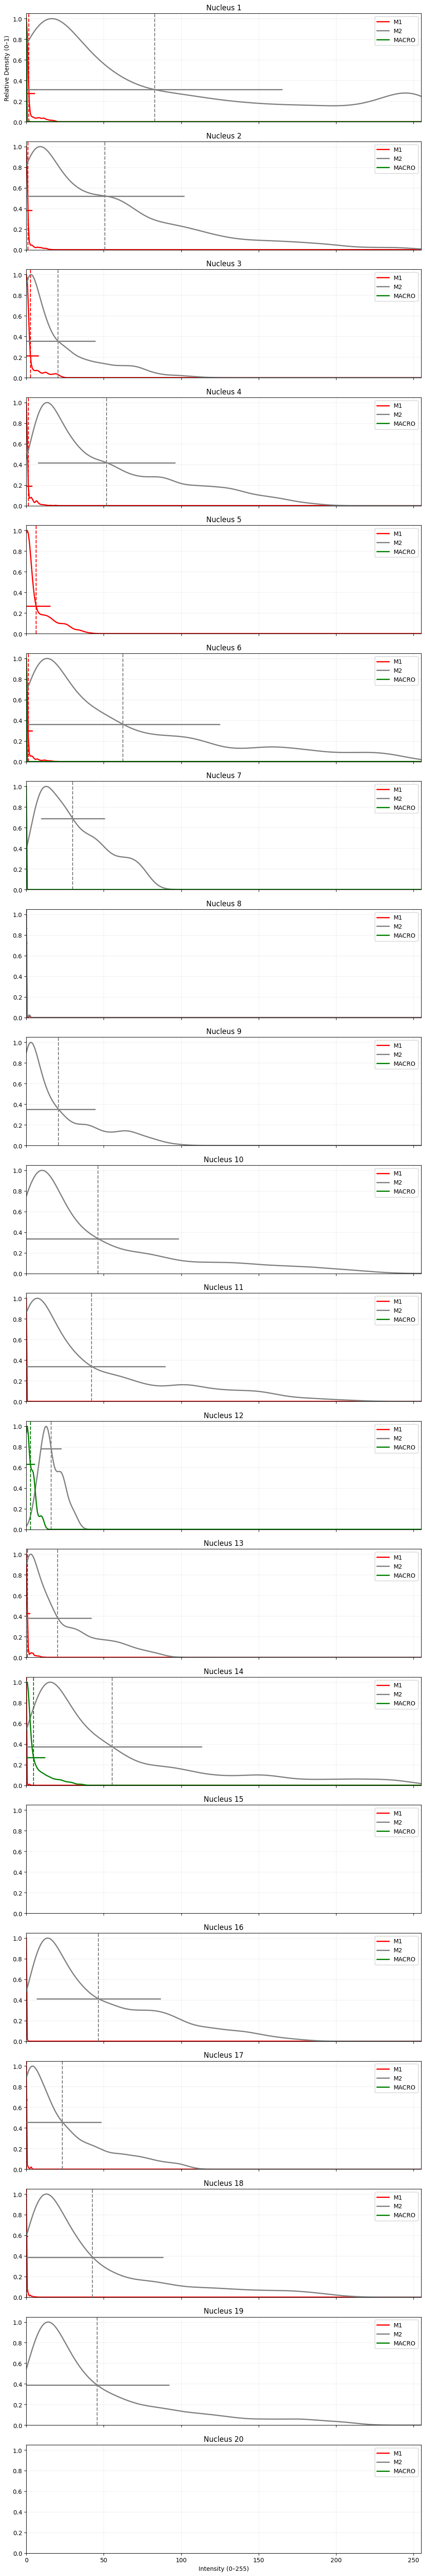

In [38]:
# --- REQUIRE: hist_data must exist in the form hist_data[n][condition] = list(values) ---
# e.g. hist_data = {1: {'MACRO': [...], 'CD3': [...], 'CD20': [...]}, 2: {...}, ...}

# Derive nuclei and condition list from hist_data
nuclei = sorted(hist_data.keys())
if len(nuclei) == 0:
    raise ValueError("hist_data is empty. Fill hist_data before plotting.")

max_n = max(nuclei)
all_conditions = sorted({cond for ndata in hist_data.values() for cond in ndata.keys()})

# Assign consistent colors per condition
color_cycle = plt.cm.tab10
condition_colors = {cond: color_cycle(i % 10) for i, cond in enumerate(all_conditions)}

# Limit figure size to prevent matplotlib rendering errors
max_subplots = min(max_n, 20)  # Cap at 20 subplots
height = min(3 * max_subplots, 60)  # Cap height at 60 inches

# Prepare multi-row figure (one subplot per nucleus)
fig, axes = plt.subplots(max_subplots, 1, figsize=(10, height), sharex=True)
if max_subplots == 1:
    axes = [axes]

x_grid = np.linspace(0, 255, 400)

# Only plot nuclei that fit in the subplot grid
nuclei_to_plot = nuclei[:max_subplots]

for idx, n in step_progress(enumerate(nuclei_to_plot), total=len(nuclei_to_plot), desc='Step 15C - Plot Nucleus KDEs'):
    ax = axes[idx]  # Use subplot index instead of nucleus number
    ax.set_title(f"Nucleus {n}")
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.2)

    # For each condition, plot density if data exists
    for cond in all_conditions:
        vals = np.array(hist_data.get(n, {}).get(cond, []))
        if stain_complete_df['Color'][cond] != 'WHITE':
            color = stain_complete_df['Color'][cond]  
        else:
            color = 'GRAY'

        if vals.size == 0:
            # no data for this nucleus & condition: skip curve plotting
            continue

        # try KDE, fallback if singular
        y_grid = None
        try:
            kde = gaussian_kde(vals)
            y_grid = kde(x_grid)
        except Exception:
            # fallback: create a narrow Gaussian around the mean (handles zero-variance)
            mean_val = vals.mean()
            bw = 1.0  # small bandwidth fallback
            y_grid = np.exp(-0.5 * ((x_grid - mean_val) / bw) ** 2)
        
        # normalize y to 0-1
        if y_grid.max() > 0:
            y_norm = y_grid / y_grid.max()
        else:
            y_norm = y_grid

        # plot density curve
        ax.plot(x_grid, y_norm, linewidth=2, color=color)

        # compute mean and std from raw vals
        mean_val = float(vals.mean())
        std_val = float(vals.std())

        # vertical mean line (same color)
        ax.axvline(mean_val, linestyle='--', linewidth=1.5, color=color)

        # y position for std-line: read normalized KDE at mean (interpolate)
        y_at_mean = np.interp(mean_val, x_grid, y_norm)

        # horizontal std line from mean-std to mean+std (clamped to axis)
        x_start = max(0.0, mean_val - std_val)
        x_end = min(255.0, mean_val + std_val)
        ax.hlines(y_at_mean, x_start, x_end, linewidth=2, color=color)

    # Build a legend showing all conditions with their assigned color (consistent across plots)
    legend_handles = [Line2D([0], [0], color=stain_complete_df['Color'][c] if stain_complete_df['Color'][c] != 'WHITE' else 'GRAY', lw=2) for c in all_conditions]
    ax.legend(legend_handles, all_conditions, loc='upper right', framealpha=0.9)

    if n == nuclei_to_plot[-1]:
        ax.set_xlabel("Intensity (0–255)")

axes[0].set_ylabel("Relative Density (0–1)")
plt.tight_layout()
plt.show()

In [39]:
# Full block: one nucleus per page, 3 channel crops + merged in one horizontal row
styles = getSampleStyleSheet()

create_row_pdf(
    output_pdf=Path(input_file).stem + "_nuclei_marker.pdf",
    pad=20,
    thumb_size=(2.0 * inch, 2.0 * inch)
)

PDF saved to: EB-015_72h_M2_CUBE_20x_nuclei_marker.pdf


In [40]:
nuc_3D_export=False

# --- VTK 3D crop of a single nucleus ----------------------------------------
# Saves a 30x30x30 voxel cube centered on the chosen nucleus as a VTK file.
# Each voxel stores:
#   Nuclei_label     : value from im_segmentation_stack['Nuclei']
#   Cytoplasm_label  : value from im_segmentation_stack['Cytoplasm']
#   <COND>_<MARKER>  : equalized intensity from im_final_stack['Equalized image']
#                      for every non-NUCLEI channel
# -----------------------------------------------------------------------------
if nuc_3D_export:
    nuc_label = int(input("Enter nucleus label number to export: "))
    
    # -- centroid -----------------------------------------------------------------
    nuc_vol = im_segmentation_stack['Nuclei']           # shape (Z, Y, X)
    mask = (nuc_vol == nuc_label)
    if not np.any(mask):
        raise ValueError(f"Nucleus {nuc_label} not found in im_segmentation_stack['Nuclei'].")
    
    if 'Cytoplasm' not in im_segmentation_stack:
        raise ValueError("im_segmentation_stack['Cytoplasm'] is missing. Run cytoplasm segmentation first.")
    
    cyto_vol = im_segmentation_stack['Cytoplasm']
    
    coords = np.argwhere(mask)                          # (N, 3): each row = [z, y, x]
    centroid = np.round(coords.mean(axis=0)).astype(int)
    cz, cy, cx = centroid
    print(f"Nucleus {nuc_label} - centroid  Z={cz}  Y={cy}  X={cx}")
    
    # -- 30x30x30 bounding box ----------------------------------------------------
    SIZE = 90
    half = SIZE // 2
    Zmax, Ymax, Xmax = nuc_vol.shape
    
    z0d, z1d = cz - half, cz + half
    y0d, y1d = cy - half, cy + half
    x0d, x1d = cx - half, cx + half
    
    # clamp to image boundaries
    z0c, z1c = max(0, z0d), min(Zmax, z1d)
    y0c, y1c = max(0, y0d), min(Ymax, y1d)
    x0c, x1c = max(0, x0d), min(Xmax, x1d)
    
    # write extents inside the padded output cube
    zp0, zp1 = z0c - z0d, z0c - z0d + (z1c - z0c)
    yp0, yp1 = y0c - y0d, y0c - y0d + (y1c - y0c)
    xp0, xp1 = x0c - x0d, x0c - x0d + (x1c - x0c)
    
    def _crop3d(vol):
        """Zero-padded SIZE^3 sub-volume extracted from a (Z, Y, X) array."""
        out = np.zeros((SIZE, SIZE, SIZE), dtype=vol.dtype)
        out[zp0:zp1, yp0:yp1, xp0:xp1] = vol[z0c:z1c, y0c:y1c, x0c:x1c]
        return out
    
    # -- build per-channel arrays -------------------------------------------------
    nuclei_crop = _crop3d(nuc_vol).astype(np.int32)
    cytoplasm_crop = _crop3d(cyto_vol).astype(np.int32)
    
    eq_img = im_final_stack['Equalized image']          # shape (Z, Y, X, C)
    marker_crops = {}
    for c_idx in range(eq_img.shape[3]):
        cond = stain_df.index[c_idx]
        if cond != 'NUCLEI':
            marker = stain_df['Marker'].iloc[c_idx]
            ch_name = f"{cond}_{marker}".replace(" ", "_").replace("-", "_")
            marker_crops[ch_name] = _crop3d(eq_img[:, :, :, c_idx]).astype(np.float32)
    
    # -- assemble pyvista ImageData -----------------------------------------------
    # DIMENSIONS = (nx, ny, nz) points; origin = (x0, y0, z0) in VTK (x,y,z) order.
    # VTK point ordering: x (i) varies fastest -> numpy arr[Z,Y,X].ravel() is correct.
    grid = pv.ImageData()
    grid.dimensions = (SIZE, SIZE, SIZE)
    grid.origin = (float(x0d), float(y0d), float(z0d))
    grid.spacing = (1.0, 1.0, 1.0)
    
    grid.point_data['Nuclei_label'] = nuclei_crop.ravel()
    grid.point_data['Cytoplasm_label'] = cytoplasm_crop.ravel()
    for ch_name, crop in marker_crops.items():
        grid.point_data[ch_name] = crop.ravel()
    
    # -- save ---------------------------------------------------------------------
    out_path = str(Path(input_file).stem + f"_nuc{nuc_label}_3Dcrop.vtk")
    grid.save(out_path)
    print(f"Saved: {out_path}  ({SIZE}^3 voxels, {2 + len(marker_crops)} channels)")

## Evaluate cell distribution in the space

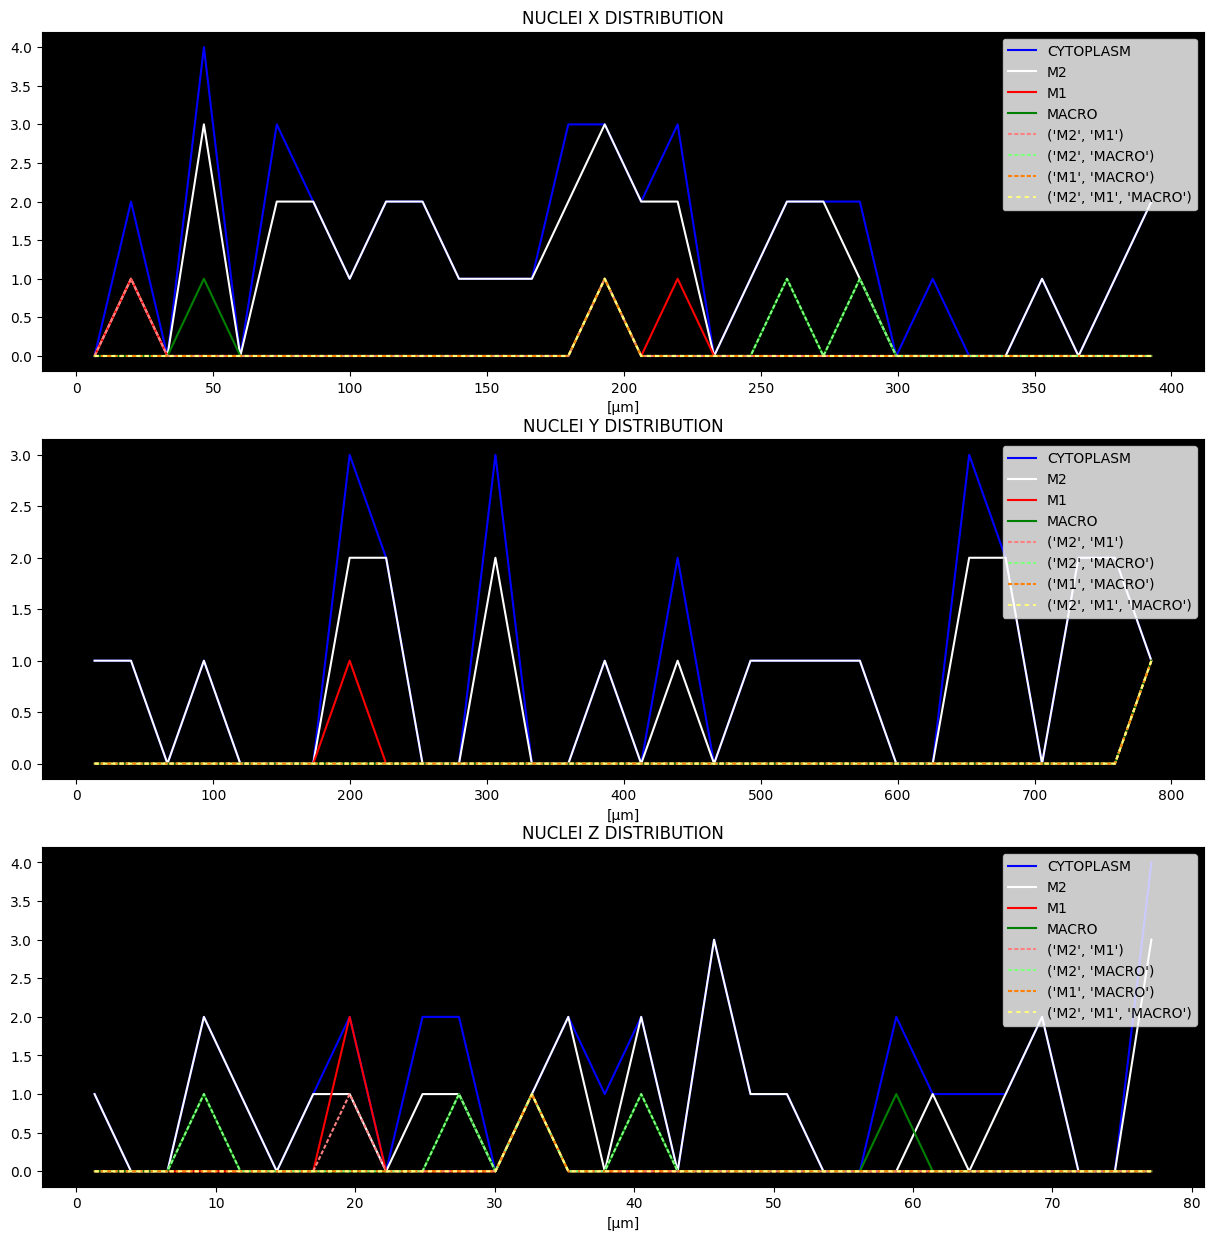

In [41]:
# Plot spatial distribution of nuclei and cells
im_in=im_final_stack['Filtered image']

fig, axs = plt.subplots(3, 1, figsize=(15, 15))
for i, marker in step_progress(enumerate(labels_df.index), total=len(labels_df.index), desc='Step 16 - Plot Spatial Distributions'):   
    xcoor = [t[0] for t in labels_df['Mean cytoplasm positions [um]'][i]]
    ycoor = [t[1] for t in labels_df['Mean cytoplasm positions [um]'][i]]
    zcoor = [t[2] for t in labels_df['Mean cytoplasm positions [um]'][i]] 
    xcount, xbins = np.histogram(xcoor, range=(0, im_in.shape[2] * r_X /zoom_factors[2]), bins=30)
    ycount, ybins = np.histogram(ycoor, range=(0, im_in.shape[1] * r_Y /zoom_factors[1]), bins=30)
    zcount, zbins = np.histogram(zcoor, range=(0, im_in.shape[0] * r_Z /zoom_factors[0]), bins=30)
    xbin_centers = (xbins[:-1] + xbins[1:]) / 2
    ybin_centers = (ybins[:-1] + ybins[1:]) / 2
    zbin_centers = (zbins[:-1] + zbins[1:]) / 2
    if (np.size(marker)==1):
        color = stain_complete_df.loc[str(labels_df['Condition'][i])]['Color']
        if color == '':
            color='BLUE'
        if (labels_df['Condition'][i]!='NUCLEI'):
            axs[0].plot(xbin_centers,xcount,label=str(labels_df['Condition'][i]),color=color)
            axs[1].plot(ybin_centers,ycount,label=str(labels_df['Condition'][i]),color=color)
            axs[2].plot(zbin_centers,zcount,label=str(labels_df['Condition'][i]),color=color)
    else:
        rgb_list=[]
        for k in range(np.size(marker)):
            if stain_df.loc[(labels_df['Condition'][i][k])]['Color']!='WHITE':
                rgb_list.append(stain_complete_df.loc[(labels_df['Condition'][i][k])]['Color'])
            else:
                rgb_list.append('GRAY')

        colors_rgb = [to_rgb(name) for name in rgb_list]

        r_total, g_total, b_total = 0.0, 0.0, 0.0

        for r, g, b in colors_rgb:
            r_total += r
            g_total += g
            b_total += b
        
        r_final = min(r_total, 1.0)
        g_final = min(g_total, 1.0)
        b_final = min(b_total, 1.0)
    
        final_rgb = (r_final, g_final, b_final)
        
        axs[0].plot(xbin_centers,xcount,label=str(labels_df['Condition'][i]),linestyle=(0, (2, np.size(marker)-1)), color=final_rgb)
        axs[1].plot(ybin_centers,ycount,label=str(labels_df['Condition'][i]),linestyle=(0, (2, np.size(marker)-1)), color=final_rgb)
        axs[2].plot(zbin_centers,zcount,label=str(labels_df['Condition'][i]),linestyle=(0, (2, np.size(marker)-1)), color=final_rgb)
        
axs[0].set_title('NUCLEI X DISTRIBUTION')
axs[0].set_xlabel('[μm]')
axs[0].legend(loc='upper right')
axs[0].set_facecolor('black')
axs[1].set_title('NUCLEI Y DISTRIBUTION')
axs[1].set_xlabel('[μm]')
axs[1].legend(loc='upper right')
axs[1].set_facecolor('black')
axs[2].set_title('NUCLEI Z DISTRIBUTION')
axs[2].set_xlabel('[μm]')
axs[2].legend(loc='upper right')
axs[2].set_facecolor('black')

## Evaluate cell size distribution

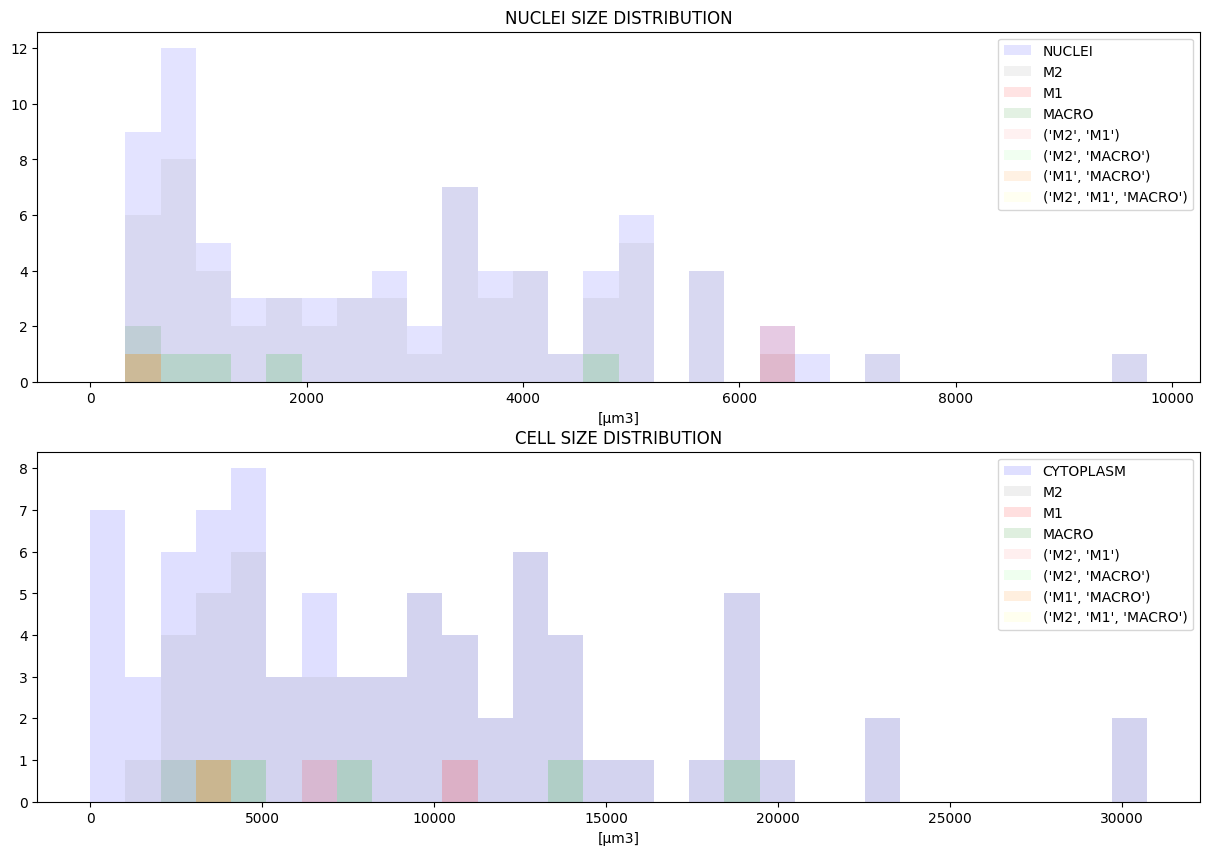

In [42]:
# Plot size distribution of nuclei and cells
fig, axs = plt.subplots(2, 1, figsize=(15, 10))
nuclei_max_size = max(x for t in labels_df['Nuclei size [um3]'] for x in t)
cytoplasm_max_size = max(x for t in labels_df['Cytoplasm size [um3]'] for x in t)
for i, marker in step_progress(enumerate(labels_df.index), total=len(labels_df.index), desc='Step 17 - Plot Size Distributions'):
    nuclei_sizes = list(labels_df['Nuclei size [um3]'][i])
    cell_sizes = list(labels_df['Cytoplasm size [um3]'][i])
    if np.size(marker)==1:
        if stain_complete_df.loc[(labels_df['Condition'][i])]['Color']=='':
            color = 'BLUE'
        else:
            if stain_complete_df.loc[(labels_df['Condition'][i])]['Color']!='WHITE':
                color = stain_complete_df.loc[str(labels_df['Condition'][i])]['Color']
            else:
                color = 'GRAY'
        #color = stain_df.loc[str(labels_df['Condition'][i])]['Color']
        #axs[0].hist(nuclei_sizes, range=(0, nuclei_max_size), bins=30, label=str(labels_df['Condition'][i]), alpha=1/len(labels_df), color=color)
    else:
        rgb_list=[]
        for k in range(np.size(marker)):
            if stain_df.loc[(labels_df['Condition'][i][k])]['Color']!='WHITE':
                rgb_list.append(stain_complete_df.loc[(labels_df['Condition'][i][k])]['Color'])
            else:
                rgb_list.append('GRAY')

        colors_rgb = [to_rgb(name) for name in rgb_list]

        r_total, g_total, b_total = 0.0, 0.0, 0.0

        for r, g, b in colors_rgb:
            r_total += r
            g_total += g
            b_total += b
        
        r_final = min(r_total, 1.0)
        g_final = min(g_total, 1.0)
        b_final = min(b_total, 1.0)
    
        color = (r_final, g_final, b_final)
        
    if labels_df['Condition'][i] != 'CYTOPLASM':    
        axs[0].hist(nuclei_sizes, range=(0, nuclei_max_size), bins=30, label=str(labels_df['Condition'][i]), alpha=1/len(labels_df), color=color)
    if labels_df['Condition'][i] != 'NUCLEI':
        axs[1].hist(cell_sizes, range=(0, cytoplasm_max_size), bins=30, label=str(labels_df['Condition'][i]), alpha=1/(len(labels_df)-1), color=color)
axs[0].set_title('NUCLEI SIZE DISTRIBUTION')
axs[0].set_xlabel('[μm3]')
axs[0].legend(loc='upper right')
axs[1].set_title('CELL SIZE DISTRIBUTION')
axs[1].set_xlabel('[μm3]')
axs[1].legend(loc='upper right')

## CREATE .VTK VOLUME

In [43]:
diamond = ndi.generate_binary_structure(rank=3, connectivity=1)
blocks_nuclei=pv.MultiBlock()
blocks_cyto=pv.MultiBlock()
blocks_PCM=pv.MultiBlock()
nuclei_stl_old=mr.Mesh()
cyto_stl_old=mr.Mesh()
PCM_stl_old=mr.Mesh()

nuc_vol=np.zeros((np.max(im_segmentation_stack['Nuclei'])+1,))
nuc_coord=np.zeros((np.max(im_segmentation_stack['Nuclei'])+1,3))
nuc_list=np.zeros((np.max(im_segmentation_stack['Nuclei'])+1,))

cyto_vol=np.zeros((np.max(im_segmentation_stack['Cytoplasm'])+1,))
cyto_coord=np.zeros((np.max(im_segmentation_stack['Cytoplasm'])+1,3))
cyto_list=np.zeros((np.max(im_segmentation_stack['Cytoplasm'])+1,))

PCM_vol=np.zeros((np.max(im_segmentation_stack['PCM'])+1,))
PCM_coord=np.zeros((np.max(im_segmentation_stack['PCM'])+1,3))
PCM_list=np.zeros((np.max(im_segmentation_stack['PCM'])+1,))

#agg_id=1

k=0
for j in step_progress(range(1,np.max(im_segmentation_stack['Nuclei'])+1), desc='Step 18 - Build VTK Volumes'):
    clear_output(wait=True)
    print('NUCLEI ' + str(j) + ' / ' + str(np.max(im_segmentation_stack['Nuclei'])))
    
    simpleVolume = mrn.simpleVolumeFrom3Darray(np.float32(im_segmentation_stack['Nuclei']==j))
    floatGrid = mr.simpleVolumeToDenseGrid(simpleVolume)
    mesh_stl = mr.gridToMesh(floatGrid , mr.Vector3f(1.0,1.0,1.0), 0.5)    
    mr.saveMesh(mesh_stl, "part_nuclei_mesh.stl" )
    
    mesh_nuclei = pv.read("part_nuclei_mesh.stl")
    if mesh_nuclei.volume>0.0:
        mesh_nuclei.decimate(target_reduction=0.8, inplace=True)

        nuc_vol[k]=mesh_nuclei.volume
        nuc_coord[k]=mesh_nuclei.center
        nuc_list[k]=j

        mesh_nuclei.cell_data['ID']=np.ones(mesh_nuclei.n_cells)*(k+1)
        mesh_nuclei.cell_data['Nuclei volume (um3)']=np.ones(mesh_nuclei.n_cells)*nuc_vol[k] * r_X * r_Y * r_Z / np.prod(zoom_factors)
        mesh_nuclei.cell_data['Z nuclei (um)']=np.ones(mesh_nuclei.n_cells)*nuc_coord[k][0] * r_Z /zoom_factors[0]
        mesh_nuclei.cell_data['Y nuclei (um)']=np.ones(mesh_nuclei.n_cells)*nuc_coord[k][1] * r_Y /zoom_factors[1]
        mesh_nuclei.cell_data['X nuclei (um)']=np.ones(mesh_nuclei.n_cells)*nuc_coord[k][2] * r_X /zoom_factors[2]
        
        blocks_nuclei.append(mesh_nuclei)
        k=k+1


    simpleVolume = mrn.simpleVolumeFrom3Darray(np.float32(im_segmentation_stack['Cytoplasm']==j))
    floatGrid = mr.simpleVolumeToDenseGrid(simpleVolume)
    mesh_stl = mr.gridToMesh(floatGrid , mr.Vector3f(1.0,1.0,1.0), 0.5)    
    mr.saveMesh(mesh_stl, "part_cyto_mesh.stl" )
    
    mesh_cyto = pv.read("part_cyto_mesh.stl")

    simpleVolume = mrn.simpleVolumeFrom3Darray(np.float32(im_segmentation_stack['PCM']==j))
    floatGrid = mr.simpleVolumeToDenseGrid(simpleVolume)
    mesh_stl = mr.gridToMesh(floatGrid , mr.Vector3f(1.0,1.0,1.0), 0.5)    
    mr.saveMesh(mesh_stl, "part_PCM_mesh.stl" )
    
    mesh_PCM = pv.read("part_PCM_mesh.stl")
    
    if mesh_cyto.volume>0.0:
        mesh_cyto.decimate(target_reduction=0.8, inplace=True)
        mesh_PCM.decimate(target_reduction=0.8, inplace=True)

        cyto_vol[k]=mesh_cyto.volume
        cyto_coord[k]=mesh_cyto.center
        cyto_list[k]=j

        PCM_vol[k]=mesh_PCM.volume
        PCM_coord[k]=mesh_PCM.center
        PCM_list[k]=j

        mesh_cyto.cell_data['ID']=np.ones(mesh_cyto.n_cells)*(k+1)
        mesh_PCM.cell_data['ID']=np.ones(mesh_PCM.n_cells)*(k+1)
        mesh_cyto.cell_data['Cellular volume (um3)']=np.ones(mesh_cyto.n_cells)*cyto_vol[k] * r_X * r_Y * r_Z / np.prod(zoom_factors)
        mesh_PCM.cell_data['PCM volume (um3)']=np.ones(mesh_PCM.n_cells)*PCM_vol[k] * r_X * r_Y * r_Z / np.prod(zoom_factors)
        mesh_cyto.cell_data['Z cell (um)']=np.ones(mesh_cyto.n_cells)*cyto_coord[k][0] * r_Z /zoom_factors[0]
        mesh_cyto.cell_data['Y cell (um)']=np.ones(mesh_cyto.n_cells)*cyto_coord[k][1] * r_Y /zoom_factors[1]
        mesh_cyto.cell_data['X cell (um)']=np.ones(mesh_cyto.n_cells)*cyto_coord[k][2] * r_X /zoom_factors[2]
        mesh_PCM.cell_data['Z PCM (um)']=np.ones(mesh_PCM.n_cells)*PCM_coord[k][0] * r_Z /zoom_factors[0]
        mesh_PCM.cell_data['Y PCM (um)']=np.ones(mesh_PCM.n_cells)*PCM_coord[k][1] * r_Y /zoom_factors[1]
        mesh_PCM.cell_data['X PCM (um)']=np.ones(mesh_PCM.n_cells)*PCM_coord[k][2] * r_X /zoom_factors[2]
        for i, marker in enumerate(labels_full_df.index):
            if (labels_full_df['Condition'][i]!='NUCLEI') & (labels_full_df['Condition'][i]!='CYTOPLASM') & (np.size(marker)==1):
                if j in list(labels_full_df['Shared labels'][i]):
                    mesh_cyto.cell_data[marker+' volume (um3)']=np.ones(mesh_cyto.n_cells)*(labels_full_df['Marker size [um3]'][i][list(labels_full_df['Shared labels'][i]).index(j)])
                    mesh_PCM.cell_data[marker+' volume (um3)']=np.ones(mesh_PCM.n_cells)*(labels_full_df['Marker size [um3]'][i][list(labels_full_df['Shared labels'][i]).index(j)])
                    mesh_cyto.cell_data[marker+' volume cytoplasm (um3)']=np.ones(mesh_cyto.n_cells)*(labels_full_df['Marker size cytoplasm [um3]'][i][list(labels_full_df['Shared labels'][i]).index(j)])
                    mesh_PCM.cell_data[marker+' volume PCM (um3)']=np.ones(mesh_PCM.n_cells)*(labels_full_df['Marker size PCM [um3]'][i][list(labels_full_df['Shared labels'][i]).index(j)])
                    mesh_cyto.cell_data[marker+' rel. vol. (-)']=np.ones(mesh_cyto.n_cells)*((labels_full_df['Marker size [um3]'][i][list(labels_full_df['Shared labels'][i]).index(j)])/((cyto_vol[k]+PCM_vol[k]) * r_X * r_Y * r_Z / np.prod(zoom_factors)))
                    mesh_PCM.cell_data[marker+' rel. vol. (-)']=np.ones(mesh_PCM.n_cells)*((labels_full_df['Marker size [um3]'][i][list(labels_full_df['Shared labels'][i]).index(j)])/((cyto_vol[k]+PCM_vol[k]) * r_X * r_Y * r_Z / np.prod(zoom_factors)))
                    mesh_cyto.cell_data[marker+' rel. vol. cytoplasm (-)']=np.ones(mesh_cyto.n_cells)*((labels_full_df['Marker size cytoplasm [um3]'][i][list(labels_full_df['Shared labels'][i]).index(j)])/(cyto_vol[k] * r_X * r_Y * r_Z / np.prod(zoom_factors)))
                    mesh_PCM.cell_data[marker+' rel. vol. PCM (-)']=np.ones(mesh_PCM.n_cells)*((labels_full_df['Marker size PCM [um3]'][i][list(labels_full_df['Shared labels'][i]).index(j)])/(PCM_vol[k] * r_X * r_Y * r_Z / np.prod(zoom_factors)))
                    mesh_cyto.cell_data[marker+' avg. intensity (-)']=np.ones(mesh_cyto.n_cells)*(labels_full_df['Avg. marker intensity'][i][list(labels_full_df['Shared labels'][i]).index(j)])
                    mesh_PCM.cell_data[marker+' avg. intensity (-)']=np.ones(mesh_PCM.n_cells)*(labels_full_df['Avg. marker intensity'][i][list(labels_full_df['Shared labels'][i]).index(j)])
                    mesh_cyto.cell_data[marker+' avg. cytoplasm int. (-)']=np.ones(mesh_cyto.n_cells)*(labels_full_df['Avg. marker intensity cytoplasm'][i][list(labels_full_df['Shared labels'][i]).index(j)])
                    mesh_PCM.cell_data[marker+' avg. PCM int. (-)']=np.ones(mesh_PCM.n_cells)*(labels_full_df['Avg. marker intensity PCM'][i][list(labels_full_df['Shared labels'][i]).index(j)])
                else:
                    mesh_cyto.cell_data[marker+' expression (um3)']=np.ones(mesh_cyto.n_cells)*(0.0)
                    mesh_cyto.cell_data[marker+' rel. expr. (-)']=np.ones(mesh_cyto.n_cells)*(0.0)
                # ass_channel_2=globals()[channel+'mag']*(NUCLEIlab==val)/np.max(globals()[channel+'mag'])
                # mesh_cyto.cell_data[channel+'_perc_rel']=np.ones(mesh_nuclei.n_cells)*(np.sum(ass_channel_2)/np.sum(NUCLEIlab==val))
        
        blocks_cyto.append(mesh_cyto)
        blocks_PCM.append(mesh_PCM)
        #k=k+1

    #j=j-1

# nuc_vol=nuc_vol[0:k-1]
# nuc_coord=nuc_coord[0:k-1]
# nuc_list=nuc_list[0:k-1]
blocks_nuclei.extract_geometry().save(Path(input_file).stem+'_NUCLEI_labelled.vtk')
blocks_cyto.extract_geometry().save(Path(input_file).stem+'_CYTOPLASM_labelled.vtk')
blocks_PCM.extract_geometry().save(Path(input_file).stem+'_PCM_labelled.vtk')

NUCLEI 79 / 79


## and .STL for markers

In [44]:
for c, marker in step_progress(enumerate(stain_complete_df.index), total=len(stain_complete_df.index), desc='Step 19 - Export Marker STL'):
    if (stain_complete_df.index[c] != 'NUCLEI') & (stain_complete_df.index[c] != 'CYTOPLASM') & (stain_complete_df.index[c] != 'PCM'):
        simpleVolume = mrn.simpleVolumeFrom3Darray(np.float32(im_segmentation_stack[stain_df.index[c]]>0))
        floatGrid = mr.simpleVolumeToDenseGrid(simpleVolume)
        mesh_stl = mr.gridToMesh(floatGrid , mr.Vector3f(1.0,1.0,1.0), 0.5)    
        mr.saveMesh(mesh_stl,Path(input_file).stem + "_" + stain_complete_df['Marker'][c] + "_mesh.stl" )

### Create a complete report XSL

In [45]:
# Export quantification results to Excel file
with pd.ExcelWriter(Path(input_file).stem + '_segmentation.xlsx', engine='xlsxwriter') as writer:
    original_stain_complete_df.to_excel(writer, sheet_name='Staining', index=True)
    xlsx_dict = {}
    columns = ['X position [um]', 'Y position [um]', 'Z position [um]', 'Nuclei size [um3]']
    # for i, marker in enumerate(labels_full_df.index):
    #     if (labels_full_df['Condition'][i] != 'NUCLEI') & (labels_full_df['Condition'][i] != 'CYTOPLASM') & (np.size(labels_full_df['Condition'][i])==1):
    #         columns.append(f"{marker} ({labels_full_df['Condition'][i]})")
    #         columns.append(f"{labels_full_df['Condition'][i]} marker size [um3]")
    for k in step_progress(range(1, int(labels_full_df['Number'][0])), desc='Step 20A - Write Nuclei Sheet'):
        row = [labels_full_df['Mean nuclei positions [um]'][0][k-1], labels_full_df['Nuclei size [um3]'][0][k-1]]
        row = [row[0][0], row[0][1], row[0][2], row[1]]
        # for i, marker in enumerate(labels_full_df.index):
        #     if (labels_full_df['Condition'][i] != 'NUCLEI') & (labels_full_df['Condition'][i] != 'CYTOPLASM') & (np.size(labels_full_df['Condition'][i])==1):
        #         shared = labels_full_df['Shared labels'][i]
        #         if k in shared:
        #             idx = list(shared).index(k)
        #             #row.append(marker)
        #             row.append(labels_full_df['Marker size [um3]'][marker][idx])
        #         else:
        #             row.extend(['', ''])
        xlsx_dict[k] = row
    cell_df = pd.DataFrame.from_dict(xlsx_dict, orient='index', columns=columns)
    cell_df.to_excel(writer, sheet_name='NUCLEI', index=True)  
    xlsx_dict = {}
    columns = ['X position [um]', 'Y position [um]', 'Z position [um]', 'Cytoplasm size [um3]']  
    for i, marker in step_progress(enumerate(labels_full_df.index), total=len(labels_full_df.index), desc='Step 20B - Prepare Cytoplasm Columns'):
        if (labels_full_df['Condition'][i] != 'NUCLEI') & (labels_full_df['Condition'][i] != 'CYTOPLASM') & (np.size(labels_full_df['Condition'][i])==1):
            #columns.append(f"{marker} ({labels_full_df['Condition'][i]})")
            columns.append(f"{labels_full_df.index[i]} marker size [um3]")
            columns.append(f"{labels_full_df.index[i]} marker size cytoplasm [um3]")
            columns.append(f"{labels_full_df.index[i]} marker size PCM [um3]")
            columns.append(f"{labels_full_df.index[i]} intensity [-]")
            columns.append(f"{labels_full_df.index[i]} STD")
            columns.append(f"{labels_full_df.index[i]} intensity cytoplasm [-]")
            columns.append(f"{labels_full_df.index[i]} STD")
            columns.append(f"{labels_full_df.index[i]} intensity PCM [-]")
            columns.append(f"{labels_full_df.index[i]} STD")
    for k in step_progress(range(1, int(labels_full_df['Number'][0])), desc='Step 20C - Write Cytoplasm Sheet'):
        row = [labels_full_df['Mean cytoplasm positions [um]'][1][k-1], labels_full_df['Cytoplasm size [um3]'][1][k-1]]
        row = [row[0][0], row[0][1], row[0][2], row[1]]
        for i, marker in enumerate(labels_full_df.index):
            if (labels_full_df['Condition'][i] != 'NUCLEI') & (labels_full_df['Condition'][i] != 'CYTOPLASM') & (np.size(labels_full_df['Condition'][i])==1):
                shared = labels_full_df['Shared labels'][i]
                if k in shared:
                    idx = list(shared).index(k)
                    #row.append(marker)
                    row.append(labels_full_df['Marker size [um3]'][marker][idx])
                    row.append(labels_full_df['Marker size cytoplasm [um3]'][marker][idx])
                    row.append(labels_full_df['Marker size PCM [um3]'][marker][idx])
                    row.append(labels_full_df['Avg. marker intensity'][marker][idx])
                    row.append(labels_full_df['STD marker intensity'][marker][idx])
                    row.append(labels_full_df['Avg. marker intensity cytoplasm'][marker][idx])
                    row.append(labels_full_df['STD marker intensity cytoplasm'][marker][idx])
                    row.append(labels_full_df['Avg. marker intensity PCM'][marker][idx])
                    row.append(labels_full_df['STD marker intensity PCM'][marker][idx])
                else:
                    row.extend([' ',' ',' ',' ',' ',' ',' ',' ',' '])
        xlsx_dict[k] = row
    cell_df = pd.DataFrame.from_dict(xlsx_dict, orient='index', columns=columns)
    cell_df.to_excel(writer, sheet_name='CYTOPLASM', index=True)
    resume_df = labels_full_df.drop(columns=['Shared labels', 'Mean nuclei positions [um]', 'Mean cytoplasm positions [um]', 'Nuclei size [um3]', 'Cytoplasm size [um3]', 'Marker size [um3]', 'Avg. marker intensity', 'Marker size cytoplasm [um3]', 'Avg. marker intensity cytoplasm', 'Marker size PCM [um3]', 'Avg. marker intensity PCM'])
    resume_df['Laser'] = [
        labels_full_df['Laser'][t] if (np.size(labels_full_df['Condition'][t])==1) else ''
        for t in range(len(labels_full_df))
    ]
    resume_df['Color'] = [
        labels_full_df['Color'][t] if (np.size(labels_full_df['Condition'][t])==1) else ''
        for t in range(len(labels_full_df))
    ]
    resume_df['%'] = [
        100.0 * labels_full_df['Number'][t] / labels_full_df['Number'][0] if labels_full_df['Condition'][t] != 'NUCLEI' else ''
        for t in range(len(labels_full_df))
    ]
    resume_df['Mean nuclei size [um3]'] = [np.mean(t) for t in labels_full_df['Nuclei size [um3]']]
    resume_df['Mean cytoplasm size [um3]'] = [np.mean(t) for t in labels_full_df['Cytoplasm size [um3]']]
    resume_df['Mean marker size [um3]'] = [
        np.mean(val) if (labels_full_df['Condition'][t] != 'NUCLEI') & (labels_full_df['Condition'][t] != 'CYTOPLASM') & (np.size(labels_full_df['Condition'][t])==1) else ''
        for t, val in enumerate(labels_full_df['Marker size [um3]'])
    ]
    resume_df.to_excel(writer, sheet_name='RECAP', index=True)

fromnumeric.py (3504): Mean of empty slice.                                                                   
_methods.py (129): invalid value encountered in scalar divide
fromnumeric.py (3504): Mean of empty slice.
_methods.py (129): invalid value encountered in scalar divide


# CREATE .inp FOR FINITE ELEMENT ANALYSIS

In [ ]:
simpleVolume = mrn.simpleVolumeFrom3Darray(np.float32(im_segmentation_stack['Nuclei']))
floatGrid = mr.simpleVolumeToDenseGrid(simpleVolume)
mesh_stl = mr.gridToMesh(floatGrid , mr.Vector3f(1.0,1.0,1.0), 0.5)

outVerts = mrn.getNumpyVerts(mesh_stl)
#print(outVerts)

outFaces = mrn.getNumpyFaces(mesh_stl.topology)

tet = tetgen.TetGen(outVerts,outFaces)
nodes,elems=tet.tetrahedralize(order=1, mindihedral=20, minratio=1.5)

tet.write('FE_segmentation_full.vtk', binary=False)

In [ ]:
meshel = meshio.read('FE_segmentation_full.vtk')
meshel.write('FE_segmentation.inp')

for c in step_progress(range(1, np.max(im_segmentation_stack['Nuclei'])+1), desc='Step 21A - Initialize Element Sets'):
    globals()[str(c)+'cell_el']=[]

for ce, x in step_progress(enumerate(elems), total=len(elems), desc='Step 21B - Assign Elements To Cells'):
    #print(np.shape(np.uint16(np.mean(nodes[x],0))))
    coord=np.int16(np.round(np.mean(nodes[x],0),0))
    step=0
    taken=False
    while not(taken):
        step+=1
        coord[coord<step]=1
        for k in [0,1,2]:
            if coord[k]>=np.shape(im_segmentation_stack['Nuclei'])[k]+1-step:coord[k]=np.shape(im_segmentation_stack['Nuclei'])[k]-1
        elemlist=im_segmentation_stack['Nuclei'][coord[0]-step:coord[0]+1+step,coord[1]-step:coord[1]+1+step,coord[2]-step:coord[2]+1+step].flatten()
        #print(elemlist)
        if sum(elemlist)>0:
            c_el=st.mode(elemlist[elemlist!=0])
            taken=True

    #print(c_el)
    if c_el!=0:
        globals()[str(c_el)+'cell_el'].append(ce+1)

f = open("FE_segmentation.inp", "a")
for c in step_progress(range(1,np.max(im_segmentation_stack['Nuclei'])+1), desc='Step 21C - Write Element Sets'):
    f.write("*Elset, elset=cell" + str(c) + "\n")
    j=1
    for t in range(1, np.size(globals()[str(c)+'cell_el'])):
        f.write(str(globals()[str(c)+'cell_el'][t]) + ",")
        j+=1
        if j>16:
            f.write("\n")
            j=1
    f.write("\n")

    
f.close()

In [ ]:
# Now insert *PART header manually
with open("FE_segmentation.inp", "r") as f:
    lines = f.readlines()

with open(Path(input_file).stem + "_FEA.inp", "w") as f:
    for line in step_progress(lines, desc='Step 21D - Write Final INP'):
        if (line=="*NODE\n"):
            f.write("*PART, name=Part-1\n")
        f.write(line)
    f.write("*END PART\n")